# MScFE 660 Risk Management — Group Work Project 3
## Interpretation of Results and Improvement of the Model
**Group 16497 — Ge Zhang, Alberto Hernandez-Espinosa**

This notebook completes the mini-capstone begun in GWP1 (problem formulation and data collection)
and GWP2 (methodology and model development). It replicates the validation procedure of
Section 4.3 of Alvi, Danish A., *Application of Probabilistic Graphical Models in Forecasting
Crude Oil Price* (University College London, 2018), reports the accuracy of the one-month-ahead
forecast of the crude oil price regime, and proposes an improved specification.

The analytical routines live in `gwp3_pipeline.py`, which is imported below; every question is
then executed explicitly so that the code, its output and the interpretation appear together.

**Question map**

| Question | Content |
|---|---|
| Q1 | Purpose and construction of the training, validation and testing sets |
| Q2 | Comparison of the validation and testing sets, and allocation of the data |
| Q3 | Regime detection: hidden Markov models fitted on the training window |
| Q4 | Re-running the Bayesian network with hill climbing, and replication of the paper |
| Q5 | Accuracy of the crude oil forecast and graphical presentation of the results |
| Q6 | Assessment of the eight contributions claimed by the dissertation |
| Q7 | Non-technical discussion |

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

import gwp3_pipeline as gwp

FIG = gwp.FIG
print("Series modelled:", gwp.SERIES)
print("Forecast target:", gwp.TARGET, "| regime labels:", gwp.LABELS)

Series modelled: ['WTI_CL', 'Brent_BZ', 'USD_Idx', 'CPI', 'Fed_Funds', 'Ind_Prod', 'WTI_Spot']
Forecast target: WTI_Spot | regime labels: ['Bear', 'Stagnant', 'Bull']


---
## Question 1 — The training, validation and testing sets

The sterilised monthly panel produced in GWP1 (199 month-end observations from January 2010,
seven variables from Yahoo Finance and the Federal Reserve Economic Data) is divided
chronologically. A chronological division is mandatory: the observations form a time series, so a
random division would let information from 2026 inform a forecast made in 2015.

* the **training set** carries the estimation burden. The Baum-Welch algorithm learns the hidden
  Markov parameters on it, the hill-climbing search learns the network structure on it, and the
  conditional probability tables are estimated on it with a K2 prior;
* the **validation set** is never used for estimation. It arbitrates between competing model
  configurations, namely the scoring function of the structure search, the maximum in-degree, the
  presence of an expert prior structure and the decision threshold;
* the **testing set** is opened once, after the configuration has been frozen, and provides an
  unbiased estimate of the error the desk should expect out of sample.

The dissertation adopts an 80:10:10 division (p. 41) and justifies the size of the hold-out
windows with the rule of thumb that at least thirty observations are required for statistical
confidence. With 199 months, an 80:10:10 division leaves only twenty months in each hold-out
window, so a 70:15:15 division is used here: it preserves the paper's logic while giving thirty
months to each of the validation and testing sets.

Total observations: 199 | variables: 7


,Set,Months,Start,End,Share,Mean_price,Mean_logret,Vol_logret,Min_price,Max_price
0,Training,139,2010-01-31,2021-07-31,69.8,69.34,0.0001,0.1231,19.23,113.39
1,Validation,30,2021-08-31,2024-01-31,15.1,83.61,0.0037,0.0950,66.14,114.38
2,Testing,30,2024-02-29,2026-07-31,15.1,73.39,-0.0000,0.1196,57.26,108.64


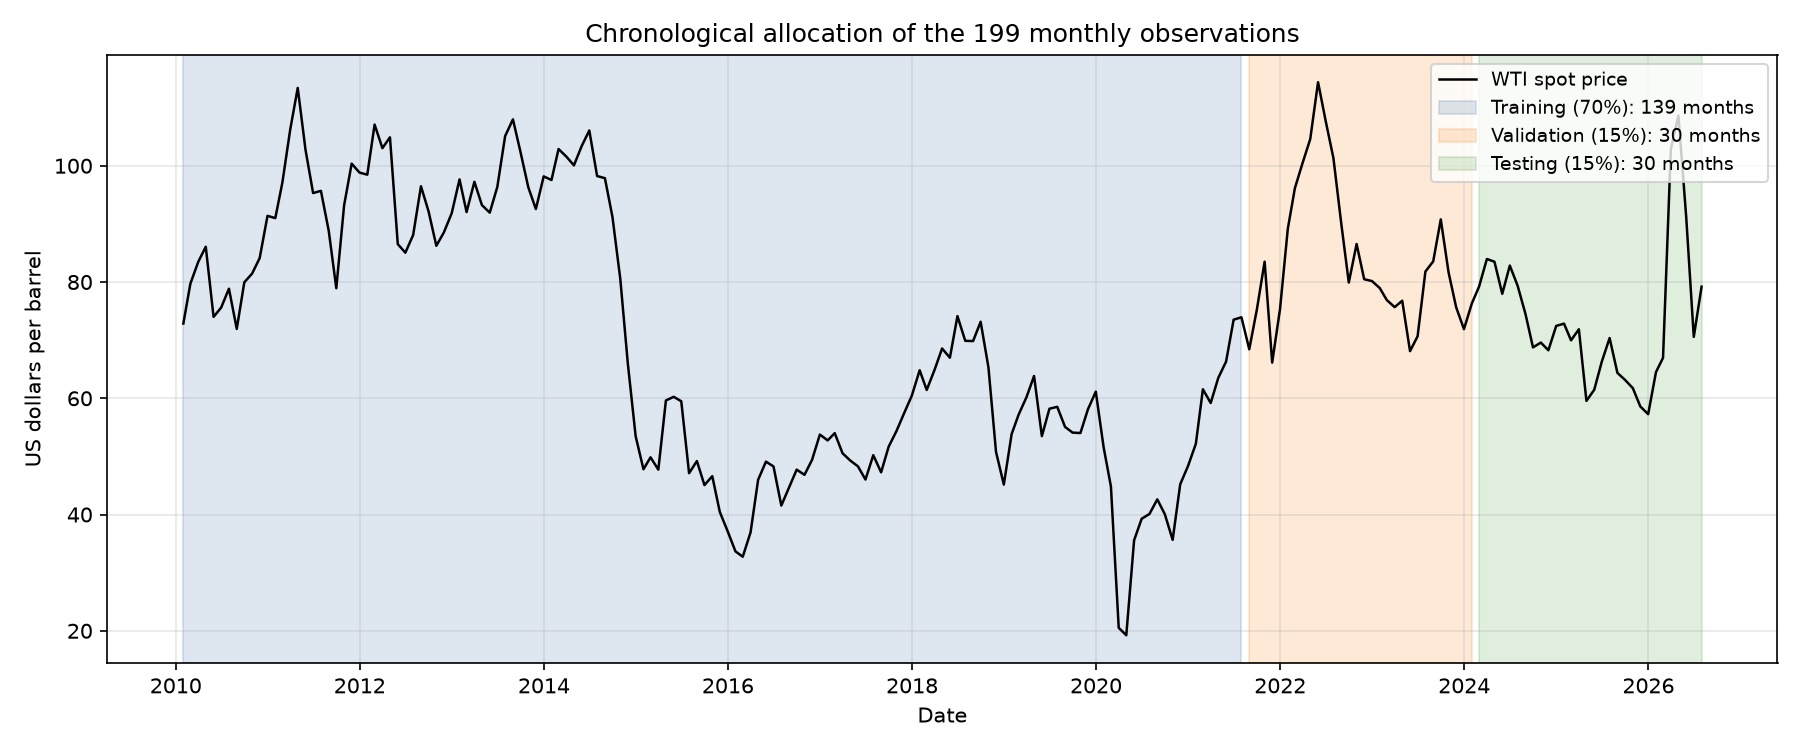

In [2]:
df, train, val, test = gwp.load_and_split(train_frac=0.70, val_frac=0.15)
summary = gwp.split_summary(df, train, val, test)
print("Total observations:", len(df), "| variables:", len(df.columns))
display(summary)
gwp.plot_allocation(df, train, val, test)
display(Image(f"{FIG}/data_allocation.png"))

**Interpretation.** The training window (139 months, January 2010 to July 2021) contains the two
structural breaks of the modern crude market, the 2014 shale glut and the 2020 pandemic collapse,
so the parameters are learned over a sample that includes both a supply-driven and a
demand-driven crisis. The validation window (30 months, August 2021 to January 2024) covers the
post-pandemic recovery and the invasion of Ukraine; the testing window (30 months, February 2024
to July 2026) covers the subsequent normalisation. Mean monthly log returns are close to zero in
the training and testing windows and mildly positive in the validation window, while volatility
is similar in the training and testing windows (12.3 and 12.0 per cent per month) and lower in
the validation window (9.5 per cent).

---
## Question 2 — Comparing the validation and testing sets

The validation and testing sets serve different purposes, so they are compared on two grounds:
whether they are statistically similar enough for a configuration chosen on one to be meaningful
on the other, and how the regimes are distributed within each.

In [3]:
r_tr = np.log(train[gwp.TARGET]).diff().dropna()
r_va = np.log(val[gwp.TARGET]).diff().dropna()
r_te = np.log(test[gwp.TARGET]).diff().dropna()

rows = []
for a, b, name in [(r_tr, r_va, "Training vs validation"),
                   (r_tr, r_te, "Training vs testing"),
                   (r_va, r_te, "Validation vs testing")]:
    ks = stats.ks_2samp(a, b)
    lev = stats.levene(a, b)
    tt = stats.ttest_ind(a, b, equal_var=False)
    rows.append(dict(Comparison=name,
                     KS_statistic=round(ks.statistic, 3), KS_p=round(ks.pvalue, 3),
                     Levene_p=round(lev.pvalue, 3), Welch_t_p=round(tt.pvalue, 3)))
display(pd.DataFrame(rows))

,Comparison,KS_statistic,KS_p,Levene_p,Welch_t_p
0,Training vs validation,0.144,0.647,0.921,0.860
1,Training vs testing,0.123,0.812,0.972,0.996
2,Validation vs testing,0.172,0.791,0.953,0.895


**Interpretation.** None of the tests rejects the null hypothesis at the five per cent level: the
distribution of monthly log returns in the validation window cannot be distinguished from the one
in the testing window, nor from the training window, in location, dispersion or shape. Model
selection carried out on the validation window is therefore not being performed on a market that
is alien to the testing window. This is a necessary condition for the exercise, not a sufficient
one, since the sample contains only thirty months on each side.

---
## Question 3 — Regime detection with hidden Markov models

Belief networks require discrete evidence. Following the dissertation, each continuous series is
converted into a sequence of three latent regimes — bear, stagnant, bull — by a three-state hidden
Markov model whose parameters are learned by Baum-Welch on the training window only, and whose
states are ordered by the arithmetic mean of the underlying monthly change.

Two emission schemes are estimated:

1. **parity emissions**, exactly as in the paper: the series is differenced and each change is
   replaced by its sign, so the alphabet has two symbols;
2. **log-return emissions**, the improvement proposed here: the emission is the winsorised monthly
   log return modelled by a Gaussian density, and the transition matrix is given a sticky
   Dirichlet prior that rewards persistence.

Decoding is performed in real time: the regime attributed to month *t* uses only the emissions
observed up to and including *t*. This matters, because the Viterbi path computed over a whole
hold-out window uses future observations to label the present and would leak information into the
forecast.

In [4]:
disc = {}
for kind in ["parity", "gaussian"]:
    d = gwp.RegimeDiscretiser(kind).fit(train)
    frame = d.transform(df)
    disc[kind] = dict(discretiser=d, frame=frame,
                      train=frame.loc[frame.index.intersection(train.index)],
                      val=frame.loc[frame.index.intersection(val.index)],
                      test=frame.loc[frame.index.intersection(test.index)])
    p = d.params[gwp.TARGET]
    print(f"--- {kind} emissions, WTI spot price ---")
    print("log-likelihood:", p["log_likelihood"],
          "| average persistence of the transition matrix:", p["persistence"])
    print("transition matrix:\n", np.array(p["transmat"]))
    if kind == "parity":
        print("emission matrix:\n", np.array(p["emissionprob"]))
    else:
        print("state means (monthly log return):", p["means"], "| state deviations:", p["sd"])
    print("regime switches over the full sample:",
          int((np.diff(frame[gwp.TARGET].values) != 0).sum()), "out of", len(frame), "months\n")

Model is not converging.  Current: 133.6292135815284 is not greater than 133.64611090460522. Delta is -0.016897323076818793


Model is not converging.  Current: 135.12412379396633 is not greater than 135.13466135759776. Delta is -0.010537563631430658


Model is not converging.  Current: 137.95241214051376 is not greater than 137.9719991672316. Delta is -0.019587026717829303


Model is not converging.  Current: 133.8785930254865 is not greater than 133.88411470889034. Delta is -0.0055216834038276374


Model is not converging.  Current: 137.8805787609427 is not greater than 137.88701219673231. Delta is -0.0064334357896029815


...

Model is not converging.  Current: 134.6463798744827 is not greater than 134.6661180024403. Delta is -0.019738127957594997


Model is not converging.  Current: 138.689566784798 is not greater than 138.75651219277114. Delta is -0.06694540797315085


Model is not converging.  Current: 137.73058048980627 is not greater than 137.74346014343874. Delta is -0.012879653632467125


Model is not converging.  Current: 137.0533835102066 is not greater than 137.05519354805233. Delta is -0.0018100378457290844


--- gaussian emissions, WTI spot price ---
log-likelihood: 138.526 | average persistence of the transition matrix: 0.7421
transition matrix:
 [[6.258e-01 3.740e-01 2.000e-04]
 [1.000e-03 8.826e-01 1.165e-01]
 [2.755e-01 6.500e-03 7.180e-01]]
state means (monthly log return): [0.0833, 0.0172, -0.1053] | state deviations: [0.113, 0.0562, 0.0961]
regime switches over the full sample: 52 out of 198 months



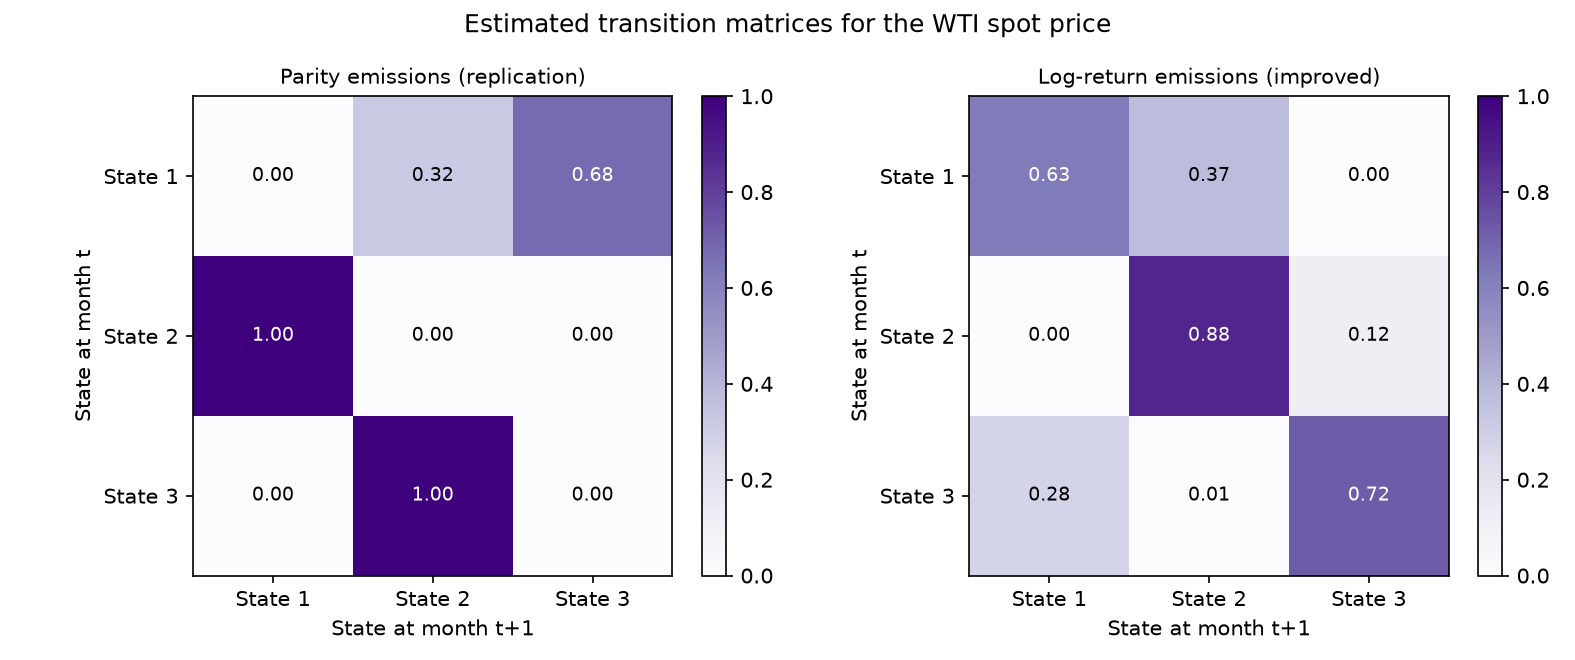

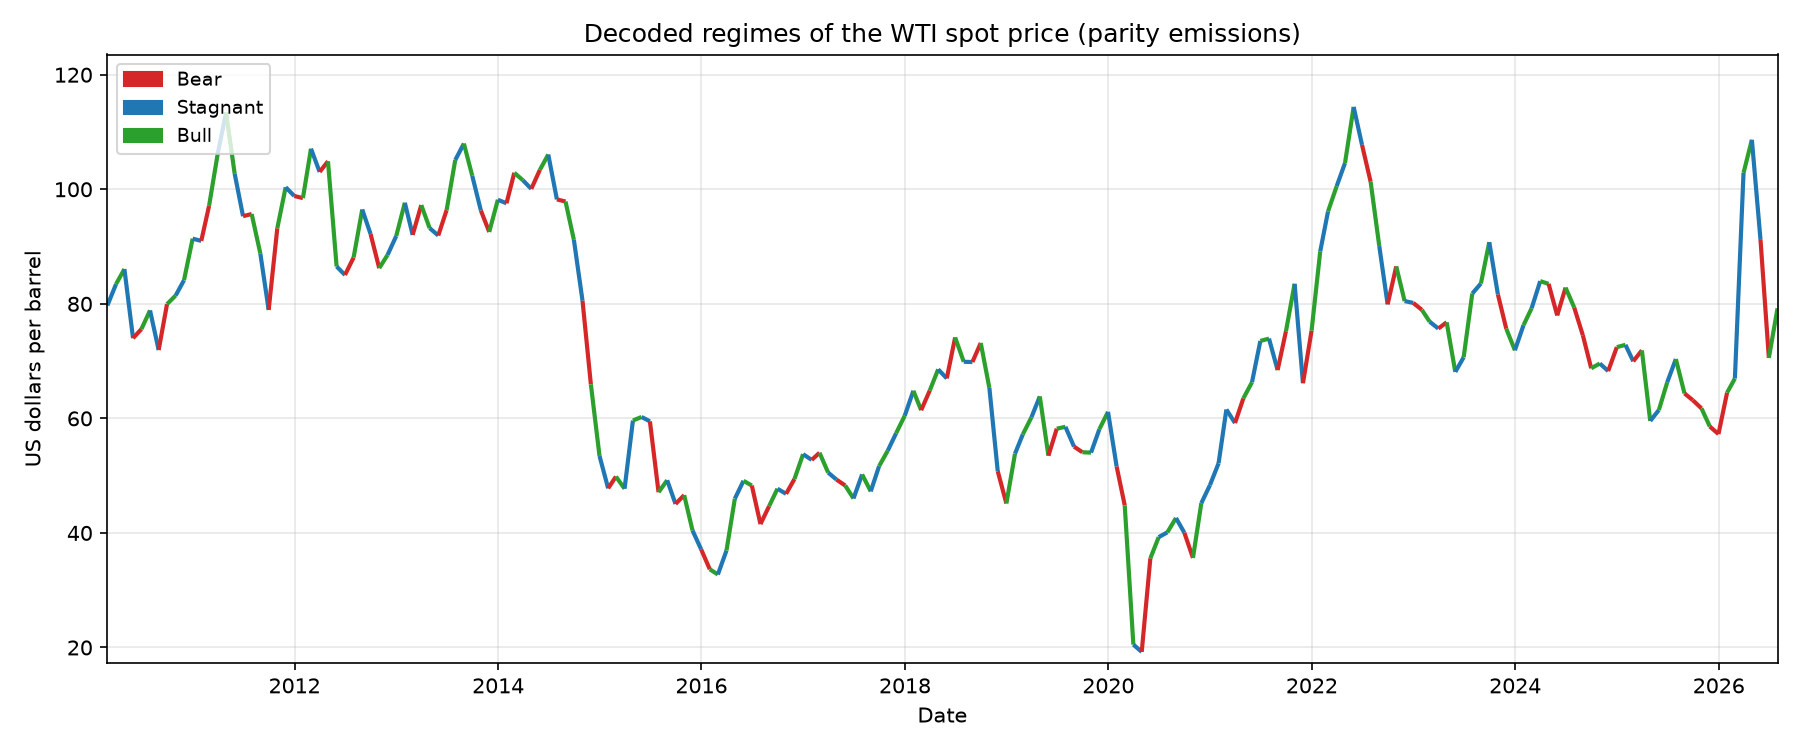

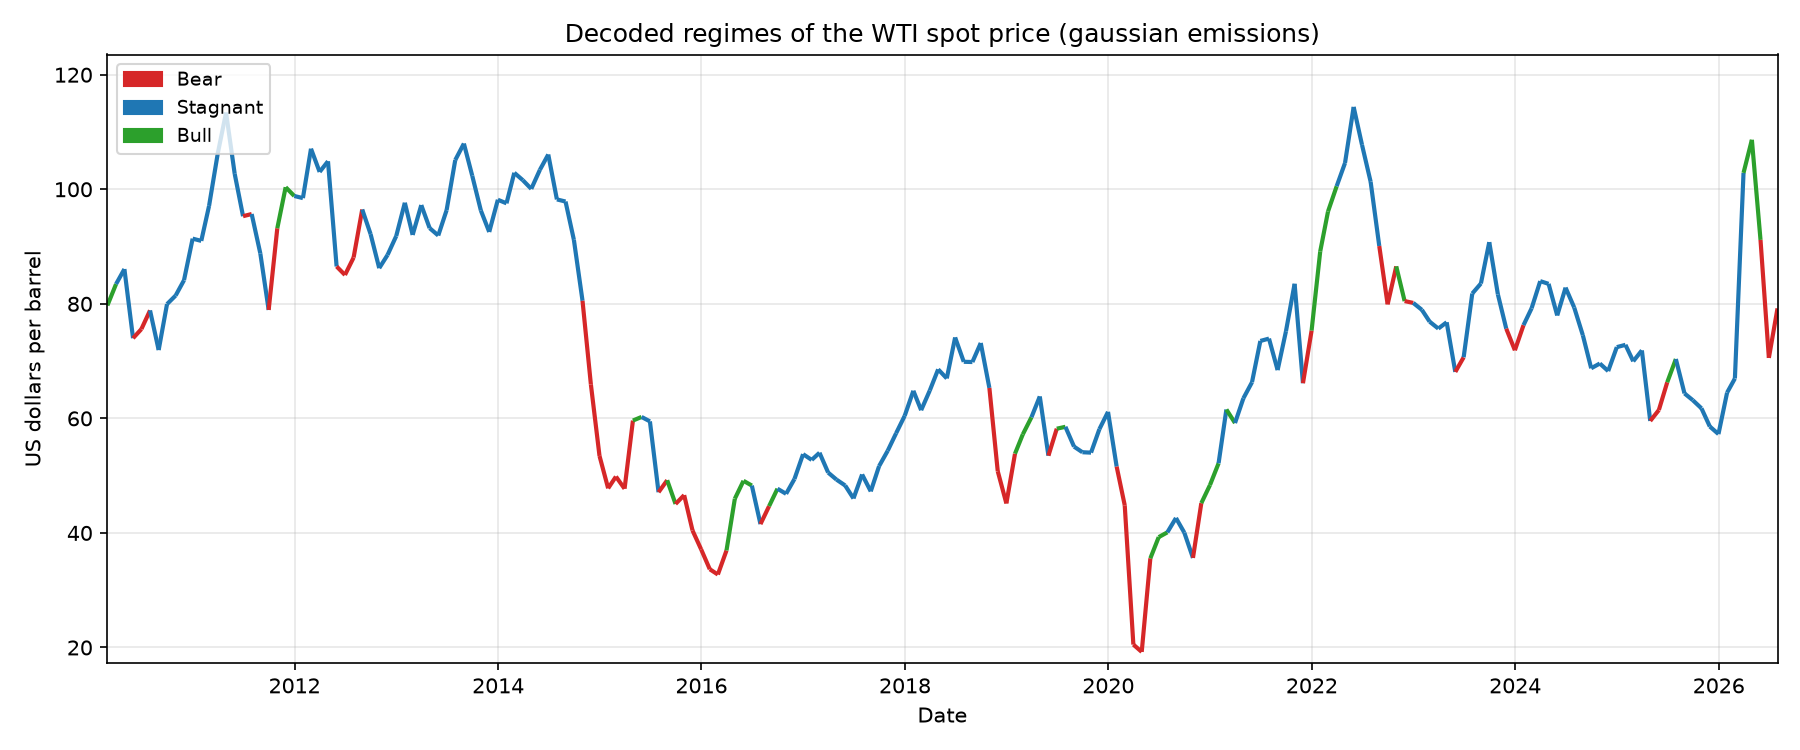

In [5]:
gwp.plot_transition_heatmaps(disc["parity"]["discretiser"].params[gwp.TARGET]["transmat"],
                             disc["gaussian"]["discretiser"].params[gwp.TARGET]["transmat"],
                             "transition_matrices.png")
display(Image(f"{FIG}/transition_matrices.png"))

for kind in ["parity", "gaussian"]:
    gwp.plot_regimes(df[gwp.TARGET].iloc[1:], disc[kind]["frame"][gwp.TARGET].values,
                     f"Decoded regimes of the WTI spot price ({kind} emissions)",
                     f"regimes_full_{kind}.png")
    display(Image(f"{FIG}/regimes_full_{kind}.png"))

The belief network consumes the discretised version of all seven series, not only the oil price,
so the two panels below show every series coloured by the regime its own hidden Markov model
attributes to it month by month. They are the visual form of the argument of this section: under
log-return emissions the colours form blocks that last several months, whereas under parity
emissions they alternate in every series.

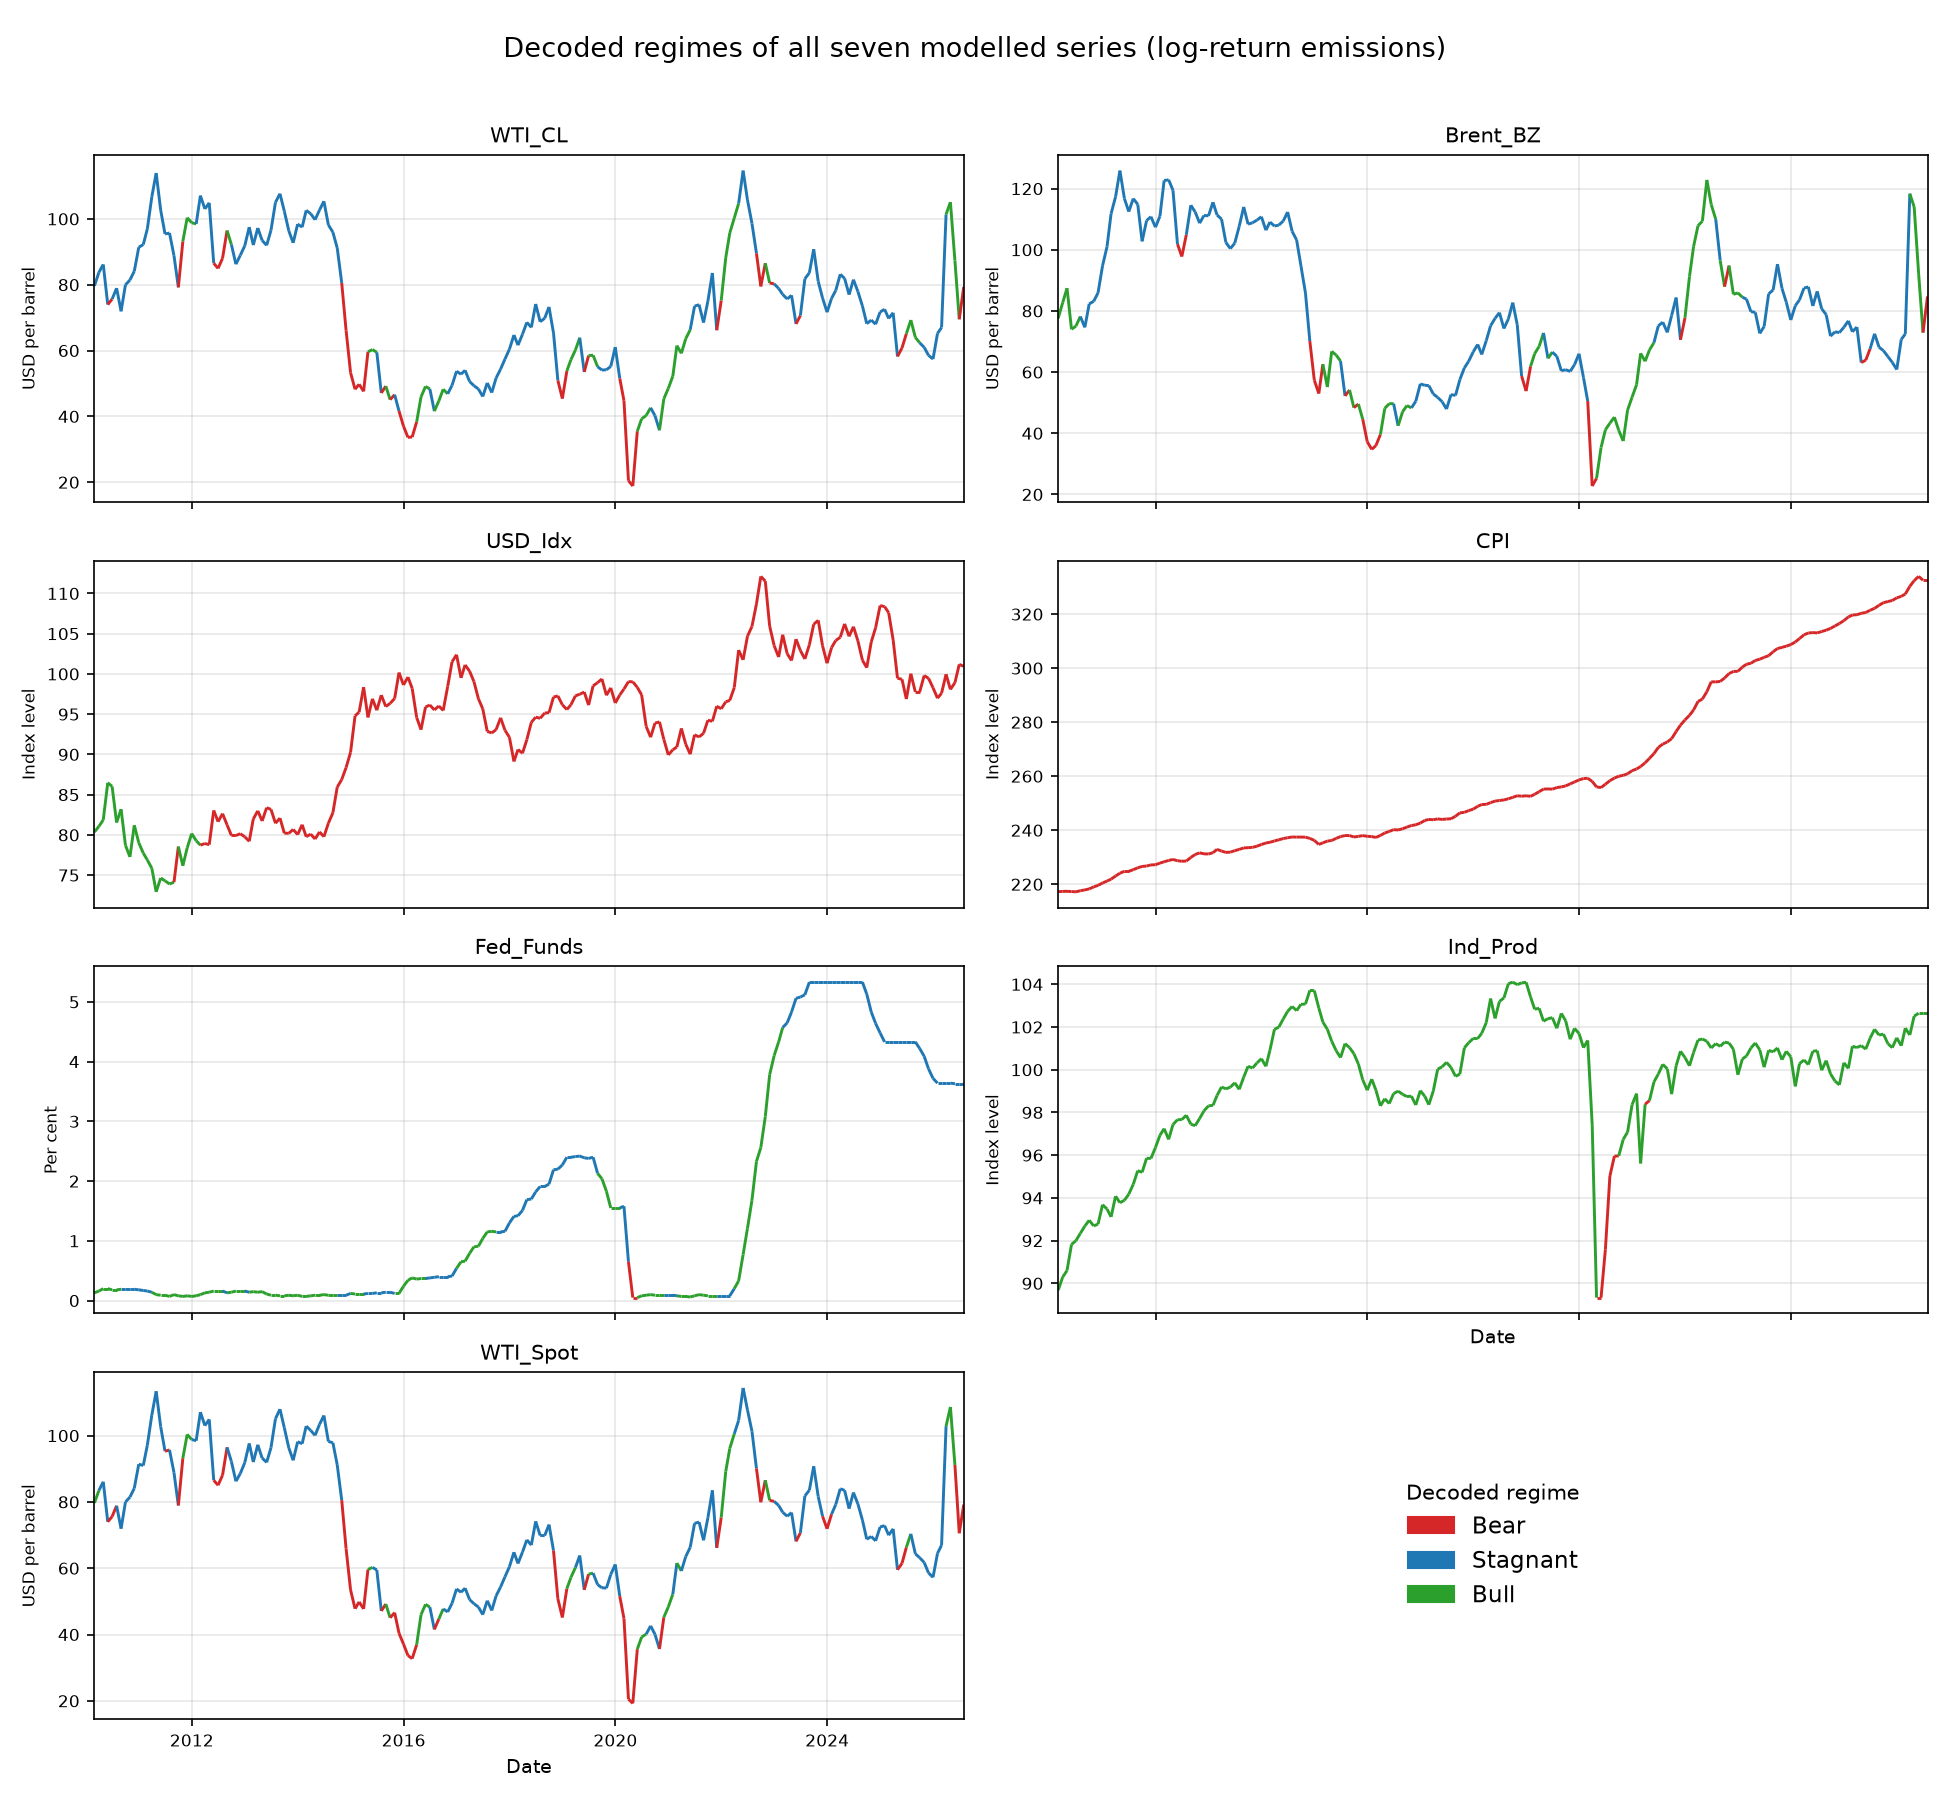

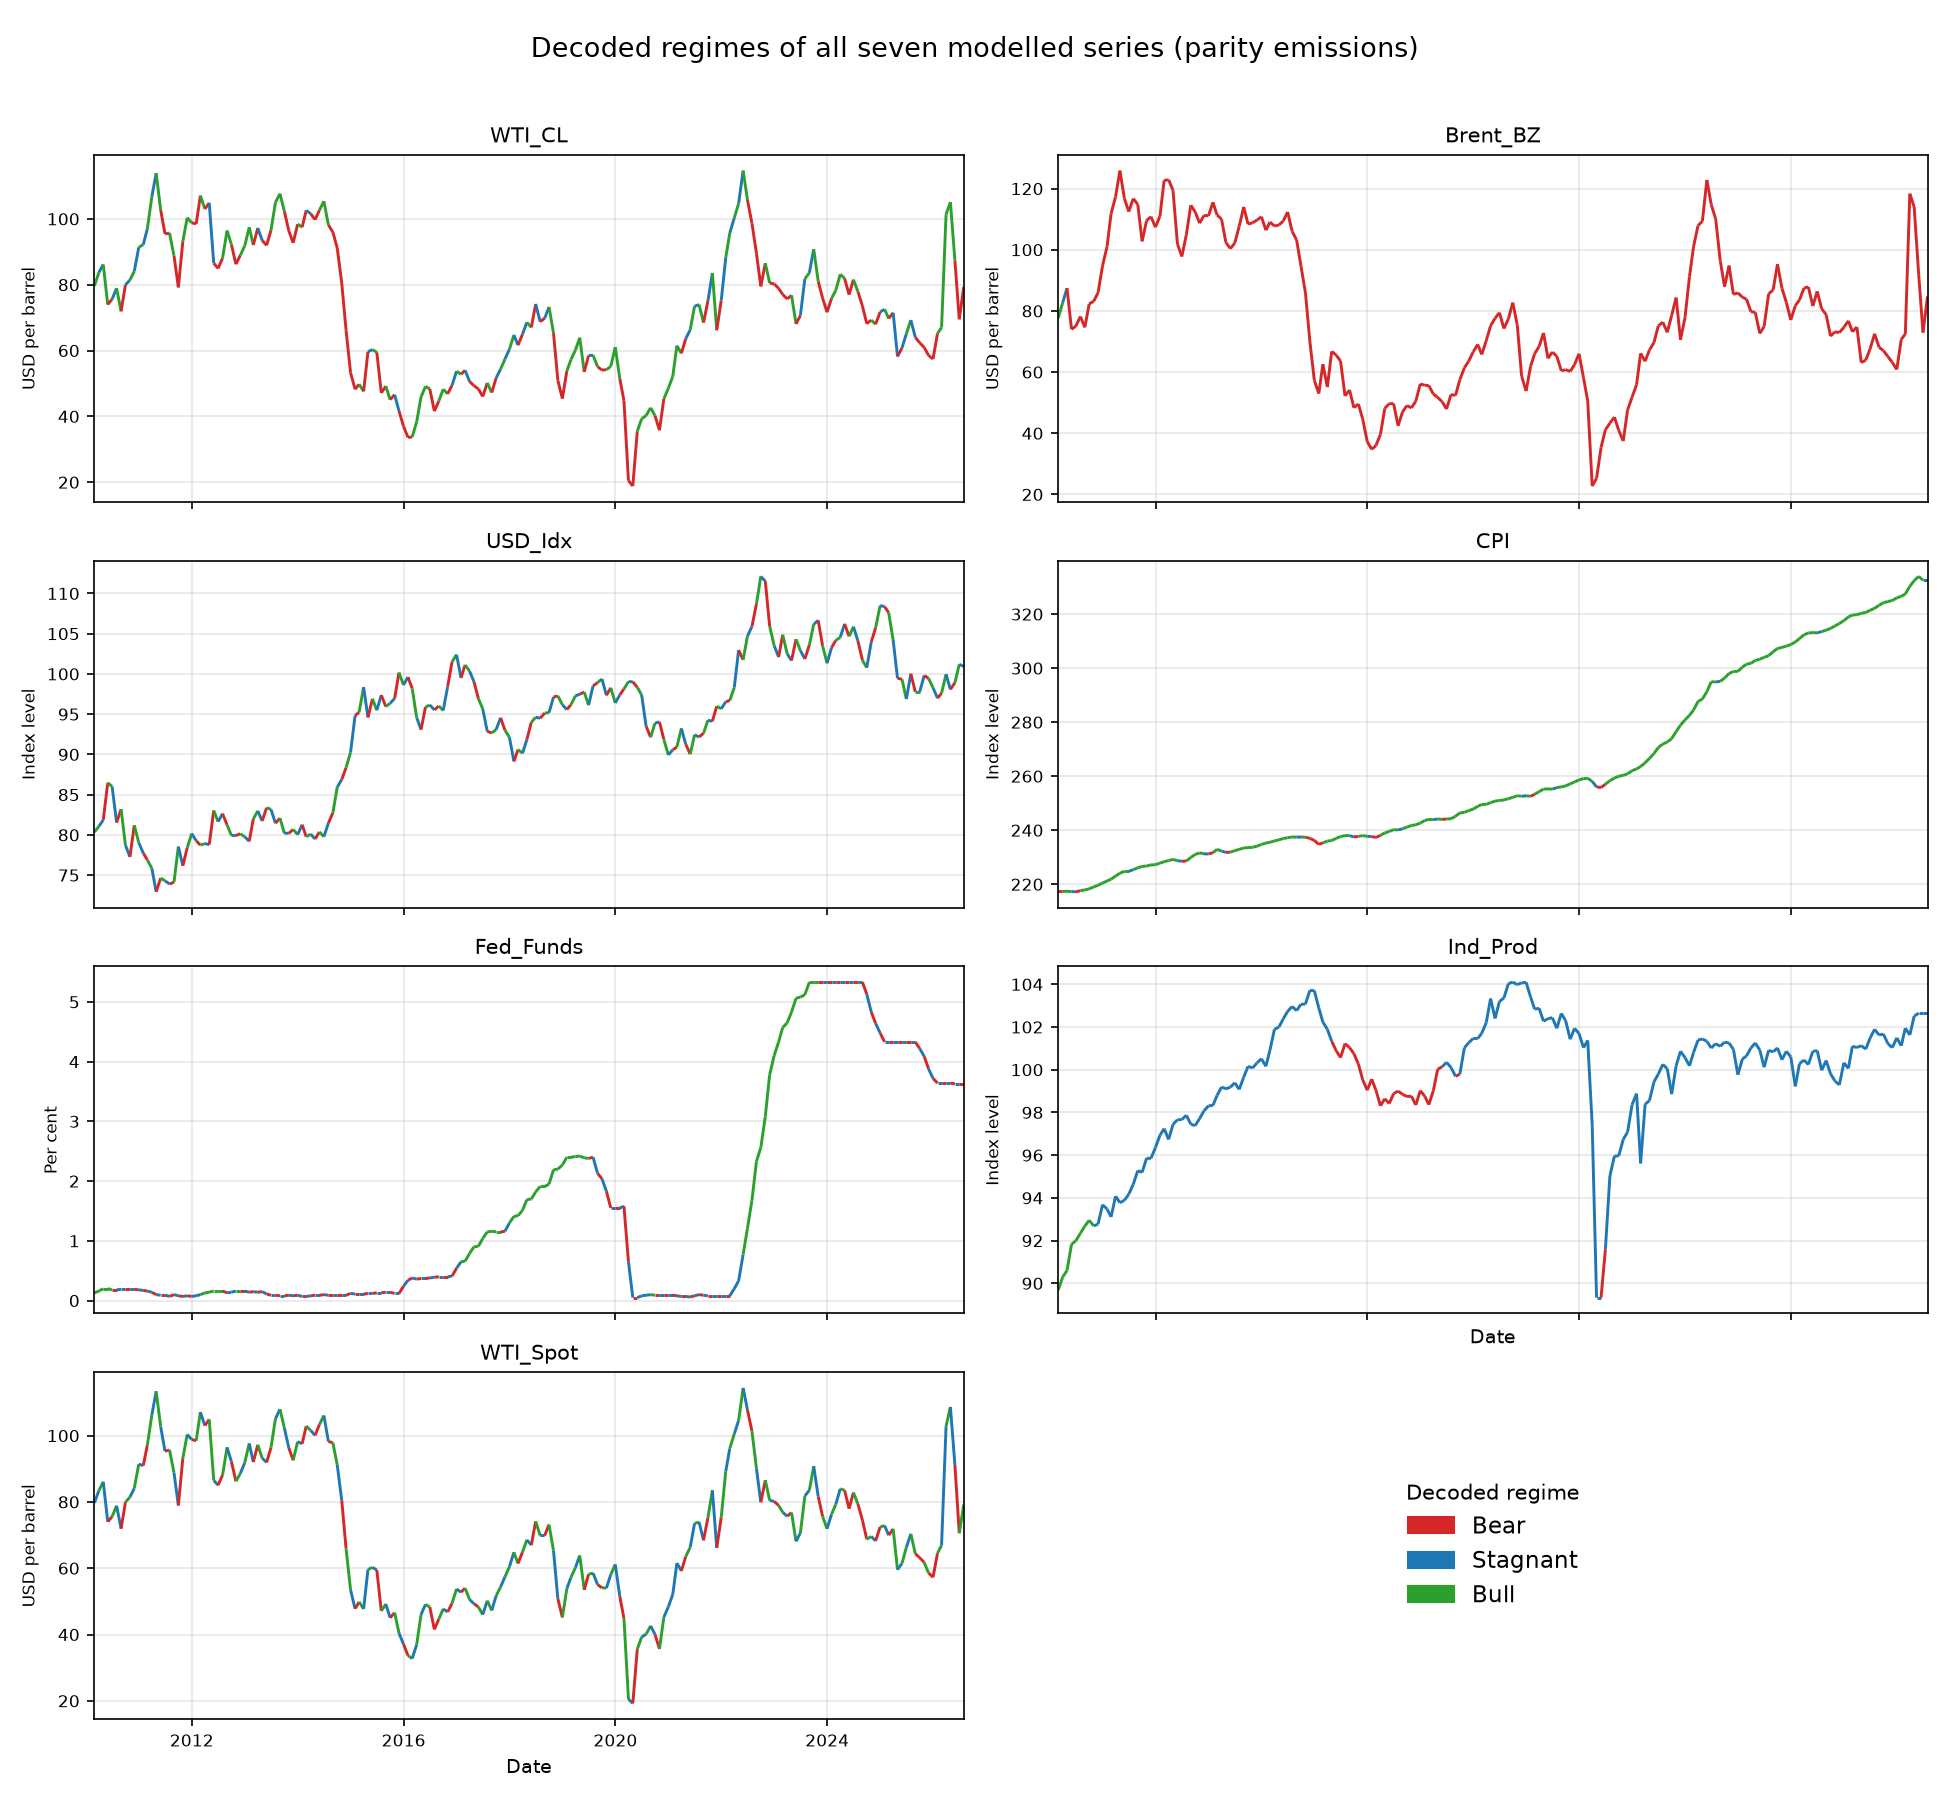

In [6]:
for kind, label in [("gaussian", "log-return"), ("parity", "parity")]:
    gwp.plot_regime_panel(df, disc[kind]["frame"],
                          f"Decoded regimes of all seven modelled series ({label} emissions)",
                          f"regimes_panel_{kind}.png")
    display(Image(f"{FIG}/regimes_panel_{kind}.png"))

In [7]:
diag = {}
for kind in ["gaussian", "parity"]:
    fr = disc[kind]["frame"]
    diag[kind] = pd.DataFrame({
        "switches": {c: int((np.diff(fr[c].values) != 0).sum()) for c in fr.columns},
        "share of modal state": {c: round(float(fr[c].value_counts(normalize=True).max()), 2)
                                 for c in fr.columns}})
print("Log-return emissions:"); display(diag["gaussian"])
print("Parity emissions:"); display(diag["parity"])

Log-return emissions:


,switches,share of modal state
WTI_CL,46,0.64
Brent_BZ,35,0.65
USD_Idx,3,0.88
CPI,0,1.00
Fed_Funds,22,0.51
Ind_Prod,4,0.97
WTI_Spot,52,0.67


Parity emissions:


,switches,share of modal state
WTI_CL,124,0.46
Brent_BZ,2,0.99
USD_Idx,197,0.33
CPI,46,0.83
Fed_Funds,142,0.38
Ind_Prod,7,0.82
WTI_Spot,189,0.37


**Interpretation of the panels.** The single-series view conceals a limitation that the panels make
plain. Under log-return emissions the three price series behave as intended — the WTI futures
switch regime 46 times, Brent 35 and the spot price 52 over 198 months — but the Consumer Price
Index never leaves its first state, industrial production spends 97 per cent of the sample in one
state and the dollar index 88 per cent. These series are close to monotone at monthly frequency,
so once a Gaussian emission is combined with a prior favouring persistence, one state absorbs
almost every month and the discretised variable becomes nearly constant. A constant variable
carries no information, which is exactly why the structure search of Question 5 discards the
Consumer Price Index, the federal funds rate and the dollar index and keeps only price-based
nodes: the macroeconomic block is silenced by the discretisation, not by the belief network.

Under parity emissions the failure is the mirror image and equally disqualifying: the dollar index
alternates in 197 of 198 months, while Brent collapses onto a single state and switches twice in
sixteen years. Neither pattern is a market regime. A natural next step, outside the scope of this
project, is to discretise trending macroeconomic series on their growth rate relative to a moving
reference rather than on their raw monthly change.

In [8]:
print("Latent meaning of the hidden states, training window, log-return emissions:")
display(gwp.regime_economics(df[gwp.TARGET], disc["gaussian"]["train"][gwp.TARGET]))
print("Latent meaning of the hidden states, training window, parity emissions:")
display(gwp.regime_economics(df[gwp.TARGET], disc["parity"]["train"][gwp.TARGET]))

shares = pd.DataFrame({
    f"{kind} / {nm}": disc[kind][p][gwp.TARGET].value_counts(normalize=True)
                       .reindex([0, 1, 2]).fillna(0).round(3)
    for kind in disc for nm, p in [("train", "train"), ("validation", "val"), ("test", "test")]})
shares.index = gwp.LABELS
print("\nRegime shares by discretisation and by set:")
display(shares)

Latent meaning of the hidden states, training window, log-return emissions:


,State,Label,Months,Mean_log_return,Volatility,Share
0,0,Bear,30,-0.1289,0.1463,21.7
1,1,Stagnant,91,0.0143,0.0532,65.9
2,2,Bull,17,0.1518,0.1350,12.3


Latent meaning of the hidden states, training window, parity emissions:


,State,Label,Months,Mean_log_return,Volatility,Share
0,0,Bear,35,-0.0669,0.0592,25.4
1,1,Stagnant,52,0.0073,0.1430,37.7
2,2,Bull,51,0.0387,0.1164,37.0



Regime shares by discretisation and by set:


,parity / train,parity / validation,parity / test,gaussian / train,gaussian / validation,gaussian / test
Bear,0.254,0.233,0.367,0.217,0.233,0.133
Stagnant,0.377,0.367,0.267,0.659,0.633,0.733
Bull,0.370,0.400,0.367,0.123,0.133,0.133


**Composition of the hold-out windows (completing Question 2).** The distributional tests above
compare raw returns, but the model forecasts regimes, so the windows must also be compared on their
regime composition. Under log-return emissions the training and validation windows are closely
matched (65.9 and 63.3 per cent stagnant), whereas the testing window is calmer: 73.3 per cent
stagnant, 13.3 per cent bear against 23.3 per cent in validation.

Two consequences follow. First, the benchmark moves with the window: always answering "stagnant"
scores 72.4 per cent on the testing set but 62.1 per cent on the validation set, so an unchanged
model appears to improve simply by being evaluated later; accuracy must always be read against the
majority benchmark of the same window. Second, the testing window contains four bear months and
four bull months — the eight months on which a directional decision would actually be taken. That
is the ultimate reason the confidence intervals reported in Question 5 are thirty points wide.

**Interpretation.** The two schemes give radically different pictures.

With **parity emissions** the estimated transition matrix has a zero diagonal: the chain leaves
every state with probability one at each step and the decoded sequence switches regime in 189 of
198 months. The three states carry no economic meaning; they encode the alternation of the sign of
the monthly change, which is what a two-symbol alphabet with no magnitude information allows the
model to see. The average conditional probability of remaining in a state is 0.00.

With **log-return emissions** and a sticky prior the picture is economically coherent: a bear state
averaging −12.9 per cent per month, a stagnant state averaging +1.4 per cent with the lowest
dispersion, and a bull state averaging +15.2 per cent. Average persistence is 0.74 and the decoded
sequence switches 52 times over 198 months. The bear state captures the second half of 2014, the
early months of 2020 and the 2025 correction, exactly the episodes an energy desk would label as
bear markets.

---
## Question 4 — Re-running the Bayesian network with hill climbing, and replication

The paper's protocol is reproduced literally. A `forecast` node duplicating the discretised WTI
spot regime is appended to the training frame; the structure is searched by hill climbing; the
conditional probability tables are estimated with a Bayesian estimator under a K2 prior; the
network is asked for the most probable state of the `forecast` node given the evidence of the
remaining variables, and that inference is shifted forward by one month to be read as a forecast
(`np.roll(prediction, 1)` in the dissertation, p. 62).

The scoring function, the maximum in-degree and the presence of an expert prior structure are
chosen on the validation set, as the paper prescribes: *"The validation step is to adjust the
model if the error is too high"* (p. 62).

In [9]:
state_names = {c: ["0", "1", "2"] for c in list(gwp.SERIES) + ["forecast"]}
A = {k: disc["parity"][k].copy() for k in ["train", "val", "test"]}
for k in A:
    A[k]["forecast"] = A[k][gwp.TARGET].values

gridA = gwp.tune_on_validation(A["train"], A["val"], "forecast", state_names, shift=True)
tableA = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in gridA])
display(tableA)
modelA = gridA[0]["model"]
print("Selected configuration:", {k: v for k, v in gridA[0].items() if k != "model"})
print("Edges of the selected network:", sorted(modelA.edges()))
print("Markov blanket of the forecast node:", sorted(modelA.get_markov_blanket("forecast")))

  0%|          | 0/23 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 932.82it/s]

   k2     in-degree=2    expert=False edges=11  validation accuracy=  0.00%


  0%|          | 0/23 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 977.72it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 1429.28it/s]

   bic-d  in-degree=None expert=True  edges= 2  validation accuracy=  0.00%


,scoring,max_indegree,expert_seeded,n_edges,val_accuracy,val_error
0,k2,NaN,True,24,13.33,86.67
1,bic-d,2.0,False,2,0.00,100.00
2,bic-d,2.0,True,2,0.00,100.00
3,bic-d,3.0,False,2,0.00,100.00
4,bic-d,3.0,True,2,0.00,100.00
5,bic-d,NaN,False,2,0.00,100.00
6,bic-d,NaN,True,2,0.00,100.00
7,bdeu,2.0,True,5,0.00,100.00
8,bdeu,3.0,True,5,0.00,100.00
9,bdeu,NaN,True,5,0.00,100.00


Selected configuration: {'scoring': 'k2', 'max_indegree': None, 'expert_seeded': True, 'n_edges': 24, 'val_accuracy': 13.33, 'val_error': 86.67}
Edges of the selected network: [('Brent_BZ', 'CPI'), ('Brent_BZ', 'Fed_Funds'), ('Brent_BZ', 'Ind_Prod'), ('Brent_BZ', 'USD_Idx'), ('Brent_BZ', 'WTI_CL'), ('Brent_BZ', 'WTI_Spot'), ('Brent_BZ', 'forecast'), ('CPI', 'USD_Idx'), ('CPI', 'WTI_CL'), ('CPI', 'WTI_Spot'), ('CPI', 'forecast'), ('Fed_Funds', 'WTI_CL'), ('Fed_Funds', 'WTI_Spot'), ('Fed_Funds', 'forecast'), ('Ind_Prod', 'USD_Idx'), ('Ind_Prod', 'WTI_CL'), ('Ind_Prod', 'WTI_Spot'), ('Ind_Prod', 'forecast'), ('USD_Idx', 'WTI_CL'), ('USD_Idx', 'WTI_Spot'), ('USD_Idx', 'forecast'), ('WTI_CL', 'WTI_Spot'), ('WTI_CL', 'forecast'), ('forecast', 'WTI_Spot')]
Markov blanket of the forecast node: ['Brent_BZ', 'CPI', 'Fed_Funds', 'Ind_Prod', 'USD_Idx', 'WTI_CL', 'WTI_Spot']


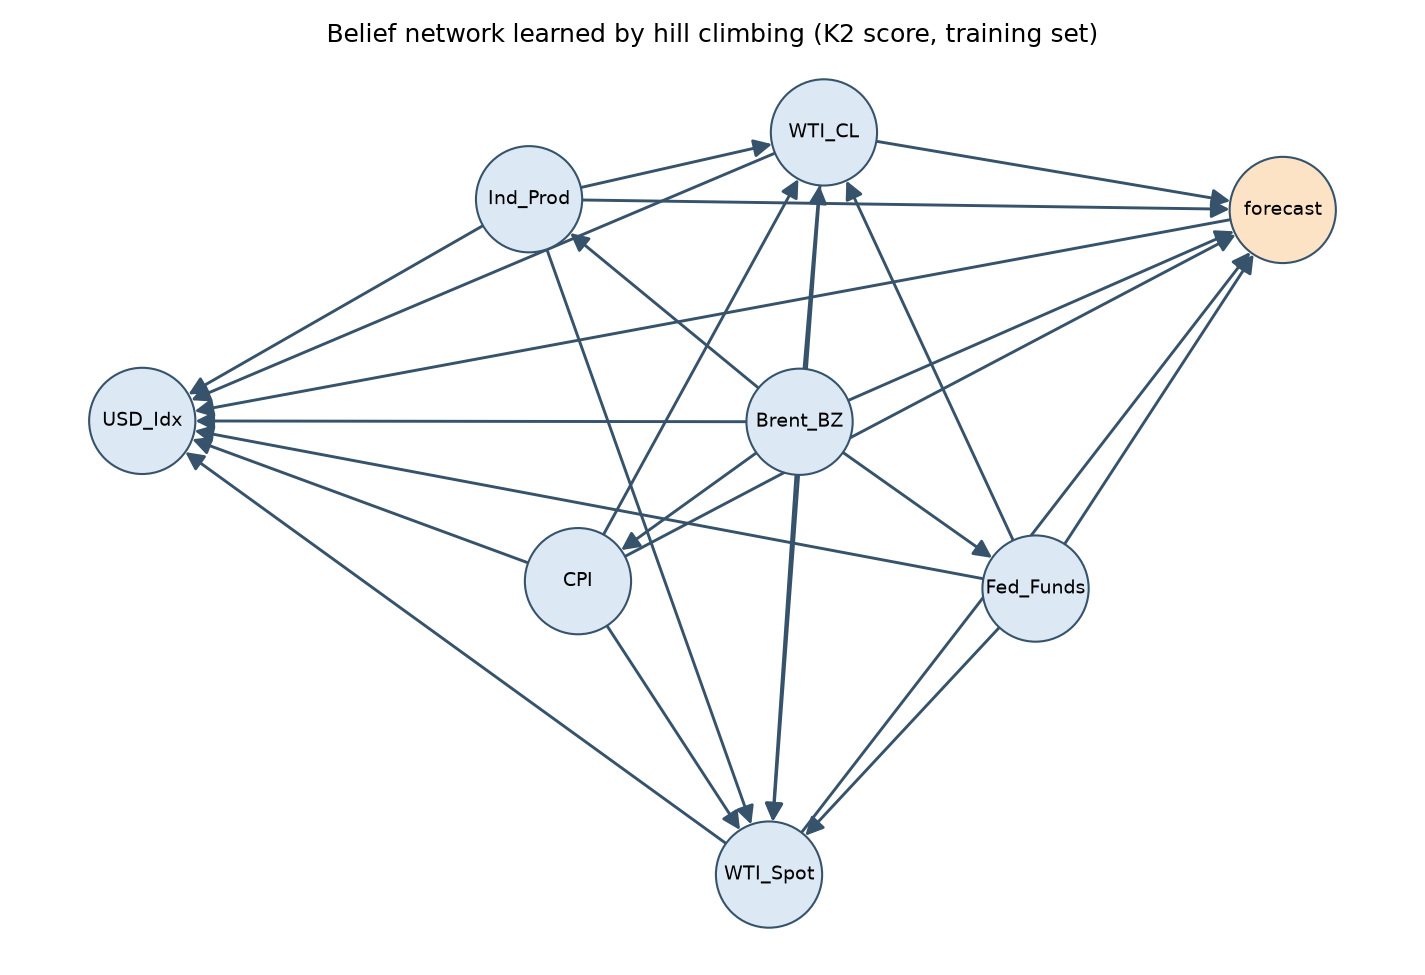

  0%|          | 0/23 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 354.84it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 350.72it/s]

,Study,Set,Months,Error,Accuracy
0,"Alvi (2018), pp. 62-63",Validation,28,67.86,32.14
1,"Alvi (2018), pp. 62-63",Testing,28,42.86,57.14
2,This replication,Validation,30,86.67,13.33
3,This replication,Testing,30,76.67,23.33


In [10]:
baseA = [r for r in gridA if r["scoring"] == "k2" and r["max_indegree"] is None
         and not r["expert_seeded"]][0]
gwp.plot_network(baseA["model"],
                 "Belief network learned by hill climbing (K2 score, training set)",
                 "network_k2_train.png")
display(Image(f"{FIG}/network_k2_train.png"))

sA_val = gwp.score_forecast(A["val"]["forecast"].values,
                            gwp.predict_regimes(modelA, A["val"], "forecast"), shift=True)
sA_test = gwp.score_forecast(A["test"]["forecast"].values,
                             gwp.predict_regimes(modelA, A["test"], "forecast"), shift=True)

comparison = pd.DataFrame([
    dict(Study="Alvi (2018), pp. 62-63", Set="Validation", Months=28, Error=67.86, Accuracy=32.14),
    dict(Study="Alvi (2018), pp. 62-63", Set="Testing", Months=28, Error=42.86, Accuracy=57.14),
    dict(Study="This replication", Set="Validation", Months=sA_val["n"],
         Error=sA_val["error"], Accuracy=sA_val["accuracy"]),
    dict(Study="This replication", Set="Testing", Months=sA_test["n"],
         Error=sA_test["error"], Accuracy=sA_test["accuracy"])])
display(comparison)

**Interpretation — were the results replicated?** Partially, and the discrepancy is informative.

The qualitative finding of the dissertation is reproduced: the procedure runs end to end on an
independent dataset, the hill-climbing search returns a densely connected network in which the
forecast node is attached to the futures and macroeconomic nodes, and the error on the validation
set is very high. The paper reports 67.9 per cent error on validation and 42.9 per cent on the
test set; our replication produces 86.7 per cent on validation and 76.7 per cent on the test set,
that is, an accuracy of 23.3 per cent, materially **below** the 33.3 per cent an uninformed guess
would achieve.

The reason is visible in Question 3. Parity emissions produce a regime sequence that alternates
almost every month. The network recovers the current regime almost perfectly, because the
`forecast` node is a copy of the target and the search discovers that deterministic link; but
shifting a nowcast forward by one month on an anti-persistent sequence converts an accurate
nowcast into a systematically wrong forecast. The paper's own protocol is therefore measuring the
persistence of the discretisation rather than the predictive content of the belief network, and it
happens to have landed on a sample where the regimes were more persistent. This is the single most
important methodological finding of our replication.

---
## Question 5 — Accuracy of the forecast, and how it is displayed

Three specifications are compared on identical months:

* the **replication model** just described;
* an **improved predictive model**, in which the target is the regime of the *following* month, so
  the network is asked to forecast rather than to reconstruct; the evidence is the current regime
  of the seven series under log-return emissions, and the configuration is again chosen on the
  validation set;
* an **expected-return decision rule** applied to the posterior of the improved model: the position
  is chosen by maximising the expected monthly log return implied by the posterior over regimes,
  with a threshold calibrated on the validation set.

In [11]:
def lead(frame):
    f = frame[gwp.SERIES].copy()
    f["forecast"] = frame[gwp.TARGET].shift(-1)
    return f.dropna().astype(int)

B = {k: lead(disc["gaussian"][k]) for k in ["train", "val", "test"]}
gridB = gwp.tune_on_validation(B["train"], B["val"], "forecast", state_names, shift=False)
display(pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in gridB]))
modelB = gridB[0]["model"]
print("Selected configuration:", {k: v for k, v in gridB[0].items() if k != "model"})
print("Edges:", sorted(modelB.edges()))
print("Markov blanket of the forecast node:", sorted(modelB.get_markov_blanket("forecast")))
print(modelB.get_cpds("forecast"))

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 1143.43it/s]

   k2     in-degree=2    expert=False edges= 7  validation accuracy= 58.62%


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 955.26it/s]

...

100%|██████████| 11/11 [00:00<00:00, 1238.45it/s]

   bic-d  in-degree=None expert=True  edges= 5  validation accuracy= 58.62%


,scoring,max_indegree,expert_seeded,n_edges,val_accuracy,val_error
0,bic-d,2.0,False,4,58.62,41.38
1,bic-d,3.0,False,4,58.62,41.38
2,bic-d,NaN,False,4,58.62,41.38
3,bic-d,2.0,True,5,58.62,41.38
4,bic-d,3.0,True,5,58.62,41.38
5,bic-d,NaN,True,5,58.62,41.38
6,k2,2.0,False,7,58.62,41.38
7,bdeu,2.0,False,10,58.62,41.38
8,bdeu,3.0,False,10,58.62,41.38
9,bdeu,NaN,False,10,58.62,41.38


Selected configuration: {'scoring': 'bic-d', 'max_indegree': 2, 'expert_seeded': False, 'n_edges': 4, 'val_accuracy': 58.62, 'val_error': 41.38}
Edges: [('Brent_BZ', 'Ind_Prod'), ('Brent_BZ', 'WTI_CL'), ('WTI_CL', 'WTI_Spot'), ('WTI_CL', 'forecast')]
Markov blanket of the forecast node: ['WTI_CL']


+-------------+---------------------+-----+---------------------+
| WTI_CL      | WTI_CL(0)           | ... | WTI_CL(2)           |
+-------------+---------------------+-----+---------------------+
| forecast(0) | 0.6296296296296297  | ... | 0.06451612903225806 |
+-------------+---------------------+-----+---------------------+
| forecast(1) | 0.07407407407407407 | ... | 0.6129032258064516  |
+-------------+---------------------+-----+---------------------+
| forecast(2) | 0.2962962962962963  | ... | 0.3225806451612903  |
+-------------+---------------------+-----+---------------------+


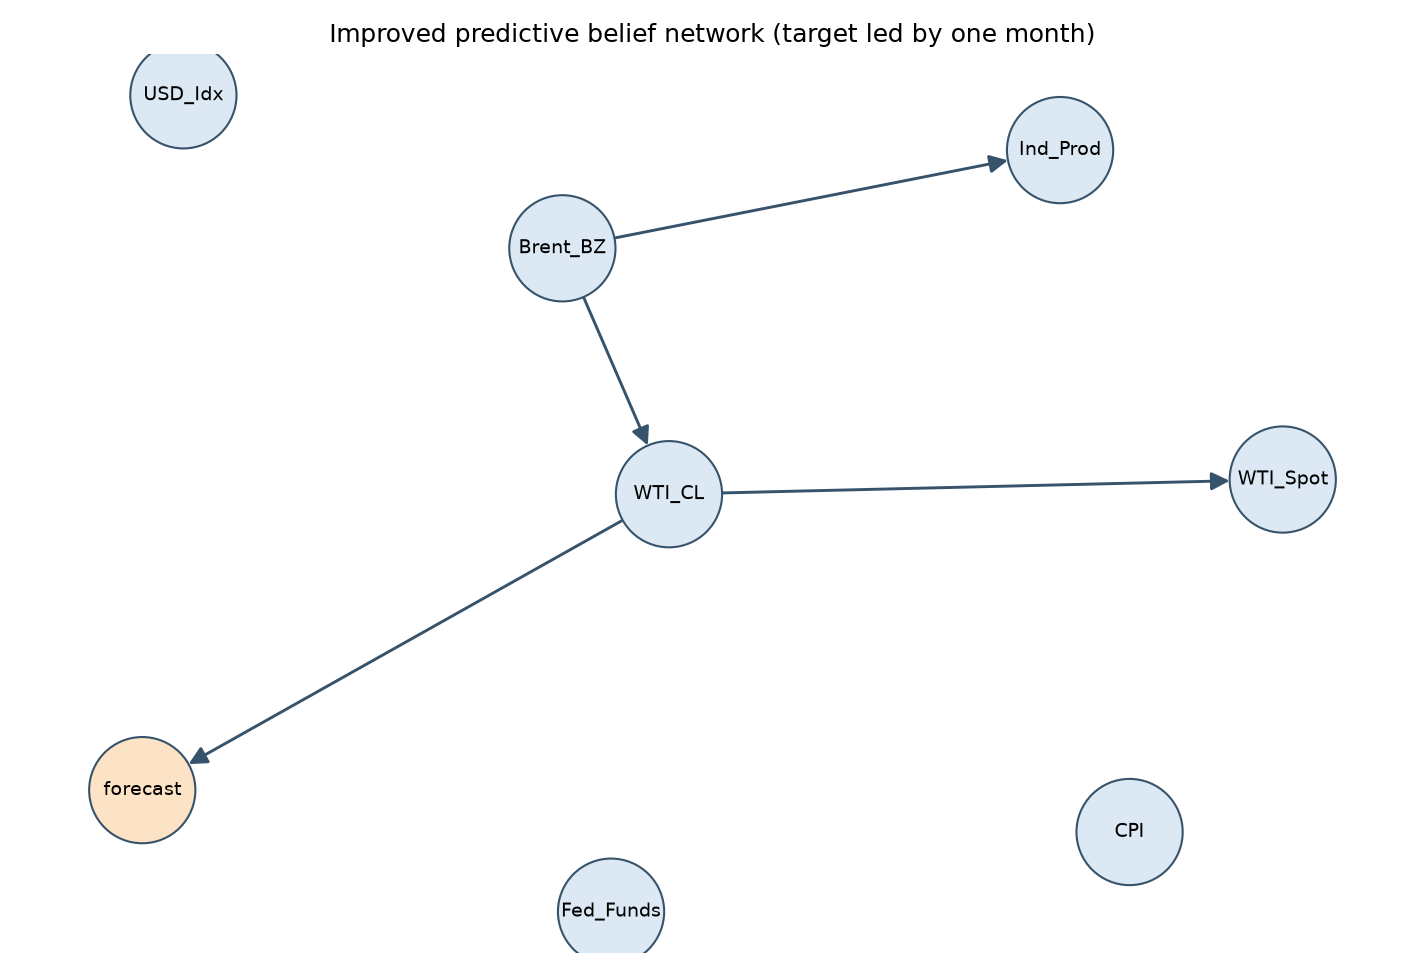

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 1210.67it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 1223.66it/s]

,Model,Set,accuracy,balanced_accuracy,macro_f1,n
0,Replication,Validation,13.33,17.32,13.03,30
1,Replication,Testing,23.33,22.35,19.26,30
2,Improved,Validation,58.62,34.39,30.95,29
3,Improved,Testing,75.86,41.67,39.31,29


In [12]:
gwp.plot_network(modelB, "Improved predictive belief network (target led by one month)",
                 "network_predictive.png")
display(Image(f"{FIG}/network_predictive.png"))

sB_val = gwp.score_forecast(B["val"]["forecast"].values,
                            gwp.predict_regimes(modelB, B["val"], "forecast"))
sB_test = gwp.score_forecast(B["test"]["forecast"].values,
                             gwp.predict_regimes(modelB, B["test"], "forecast"))
metrics = pd.DataFrame([
    dict(Model="Replication", Set="Validation", **{k: sA_val[k] for k in
         ["accuracy", "balanced_accuracy", "macro_f1", "n"]}),
    dict(Model="Replication", Set="Testing", **{k: sA_test[k] for k in
         ["accuracy", "balanced_accuracy", "macro_f1", "n"]}),
    dict(Model="Improved", Set="Validation", **{k: sB_val[k] for k in
         ["accuracy", "balanced_accuracy", "macro_f1", "n"]}),
    dict(Model="Improved", Set="Testing", **{k: sB_test[k] for k in
         ["accuracy", "balanced_accuracy", "macro_f1", "n"]})])
display(metrics)

In [13]:
econ = gwp.regime_economics(df[gwp.TARGET], disc["gaussian"]["train"][gwp.TARGET])
state_means = {int(r["State"]): float(r["Mean_log_return"]) for r in econ.to_dict("records")}

prob_val = gwp.posterior_probabilities(modelB, B["val"], "forecast")
search = []
for mg in [0.0, 0.005, 0.01, 0.02, 0.03, 0.05]:
    pv, _ = gwp.expected_return_rule(prob_val, state_means, mg)
    dm = gwp.directional_metrics(df[gwp.TARGET], B["val"].index, pv)
    sv = gwp.score_forecast(B["val"]["forecast"].values, pv)
    search.append(dict(margin=mg, coverage=dm["coverage"], hit_rate=dm["hit_rate"],
                       accuracy=sv["accuracy"],
                       terminal_value=round(gwp.strategy_value(df[gwp.TARGET], B["val"].index, pv), 2)))
search = pd.DataFrame(search)
display(search)
best_margin = float(search.sort_values(["terminal_value", "margin"],
                                       ascending=[False, True]).iloc[0]["margin"])
print("Threshold selected on the validation set:", best_margin)

prob_test = gwp.posterior_probabilities(modelB, B["test"], "forecast")
rule_pred, exp_ret = gwp.expected_return_rule(prob_test, state_means, best_margin)
sC_test = gwp.score_forecast(B["test"]["forecast"].values, rule_pred)
print("Expected-return rule on the testing set:",
      {k: sC_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1"]},
      "| Brier score:", gwp.brier_score(prob_test, B["test"]["forecast"].values))

,margin,coverage,hit_rate,accuracy,terminal_value
0,0.000,100.00,68.97,27.59,147.34
1,0.005,100.00,68.97,27.59,147.34
2,0.010,34.48,100.00,58.62,200.31
3,0.020,34.48,100.00,58.62,200.31
4,0.030,34.48,100.00,58.62,200.31
5,0.050,0.00,NaN,62.07,68.43


Threshold selected on the validation set: 0.01
Expected-return rule on the testing set: {'accuracy': 68.97, 'balanced_accuracy': 45.24, 'macro_f1': 45.46} | Brier score: 0.3591


In [14]:
yB = B["test"]["forecast"].values
maj = int(pd.Series(B["train"]["forecast"]).mode()[0])
persistence = B["test"][gwp.TARGET].values
rng = np.random.default_rng(gwp.SEED)
bench = {
    "Uninformed guess": round(100 * float(np.mean(yB == rng.integers(0, 3, len(yB)))), 2),
    "Majority regime": round(100 * float(np.mean(yB == maj)), 2),
    "Persistence": round(100 * float(np.mean(yB == persistence)), 2),
    "Belief network\n(replication)": sA_test["accuracy"],
    "Belief network\n(improved)": sB_test["accuracy"],
    "Expected-return\nrule": sC_test["accuracy"]}
display(pd.Series(bench, name="Test accuracy (%)").to_frame())

print("Exact confidence interval for the improved model:",
      gwp.accuracy_ci(round(sB_test["accuracy"] / 100 * len(yB)), len(yB)))
print("McNemar, improved model against persistence:",
      gwp.mcnemar(yB, sB_test["y_pred"], persistence))
print("McNemar, improved model against the majority regime:",
      gwp.mcnemar(yB, sB_test["y_pred"], np.full(len(yB), maj)))
print("Directional reading, improved model:",
      gwp.directional_metrics(df[gwp.TARGET], B["test"].index, sB_test["y_pred"]))
print("Directional reading, expected-return rule:",
      gwp.directional_metrics(df[gwp.TARGET], B["test"].index, rule_pred))

,Test accuracy (%)
Uninformed guess,34.48
Majority regime,72.41
Persistence,79.31
Belief network\n(replication),23.33
Belief network\n(improved),75.86
Expected-return\nrule,68.97


Exact confidence interval for the improved model: [np.float64(56.46), np.float64(89.7)]
McNemar, improved model against persistence: {'n01': 2, 'n10': 1, 'p_value': 1.0}
McNemar, improved model against the majority regime: {'n01': 0, 'n10': 1, 'p_value': 1.0}
Directional reading, improved model: {'n_months': 29, 'n_directional_calls': 3, 'coverage': 10.34, 'hit_rate': 66.67}
Directional reading, expected-return rule: {'n_months': 29, 'n_directional_calls': 9, 'coverage': 31.03, 'hit_rate': 66.67}


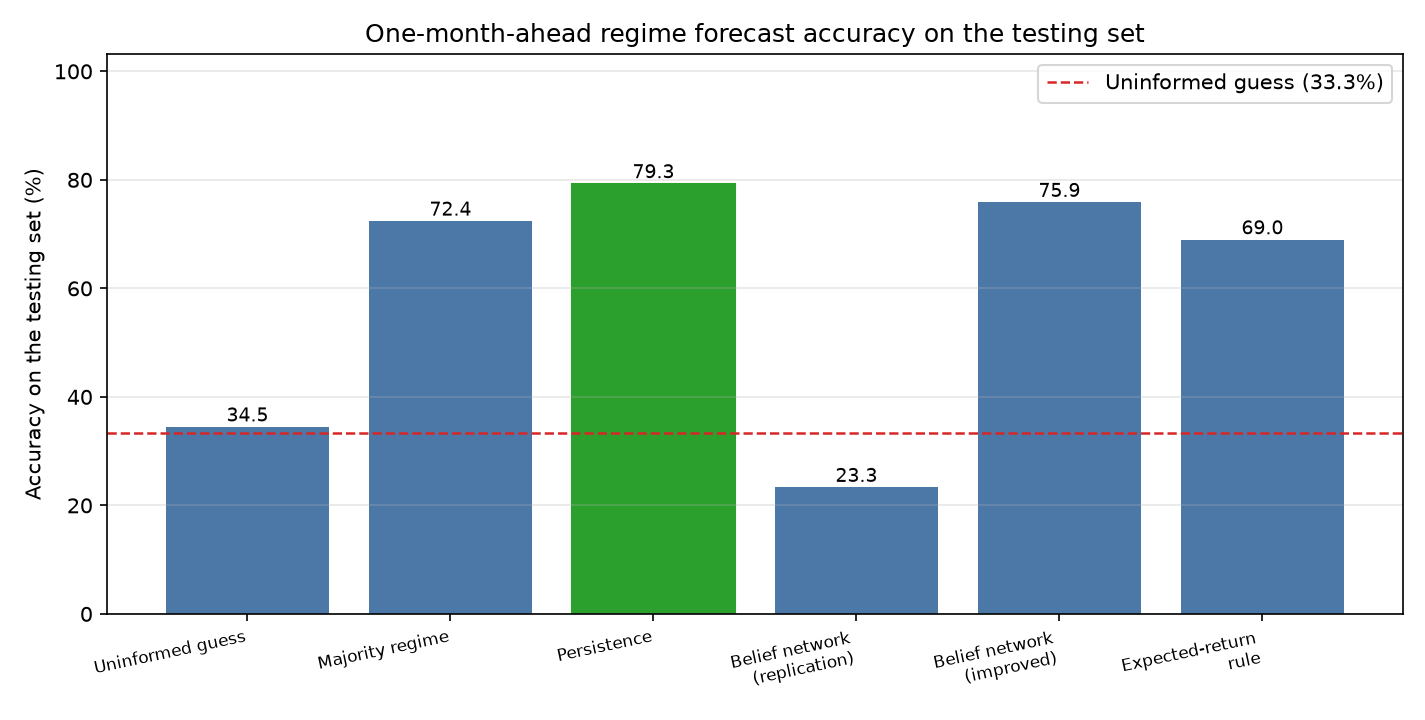

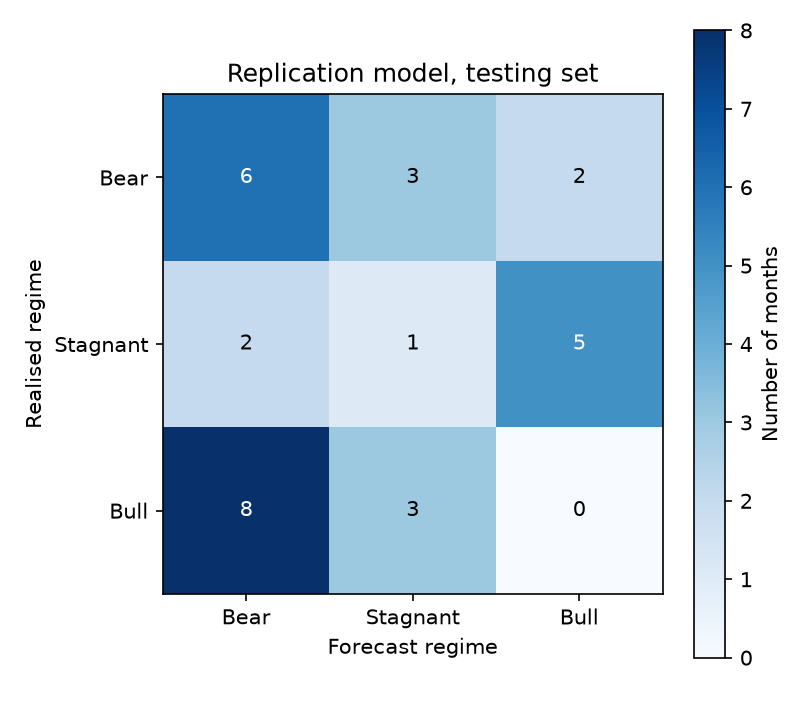

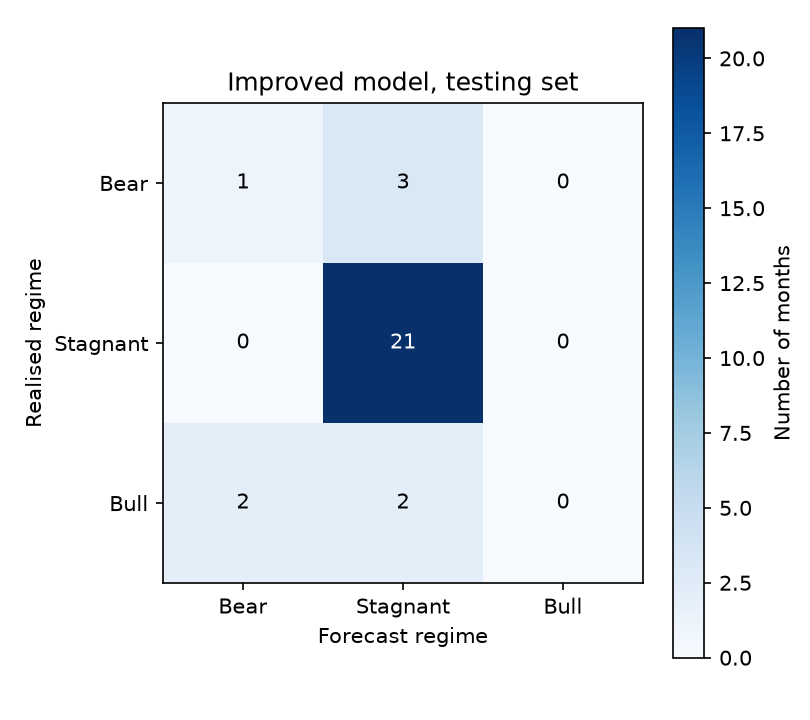

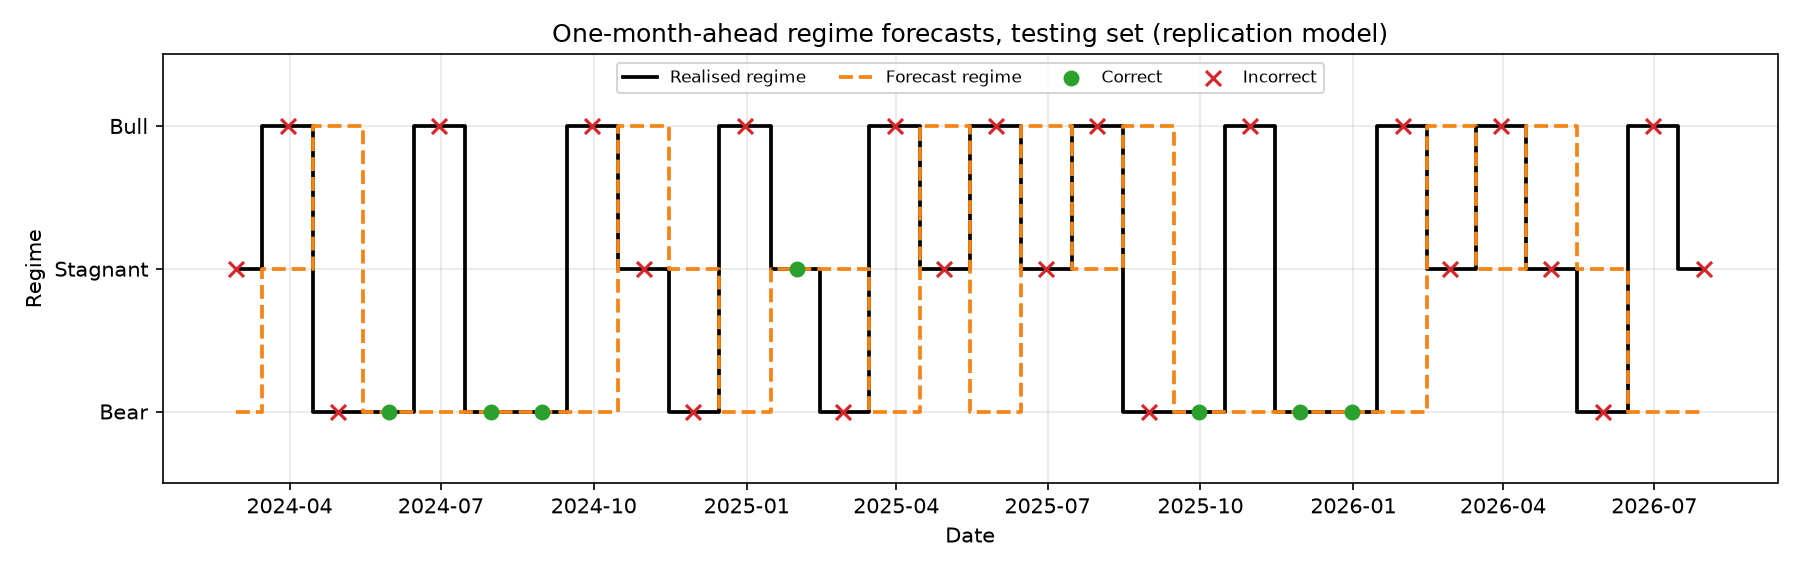

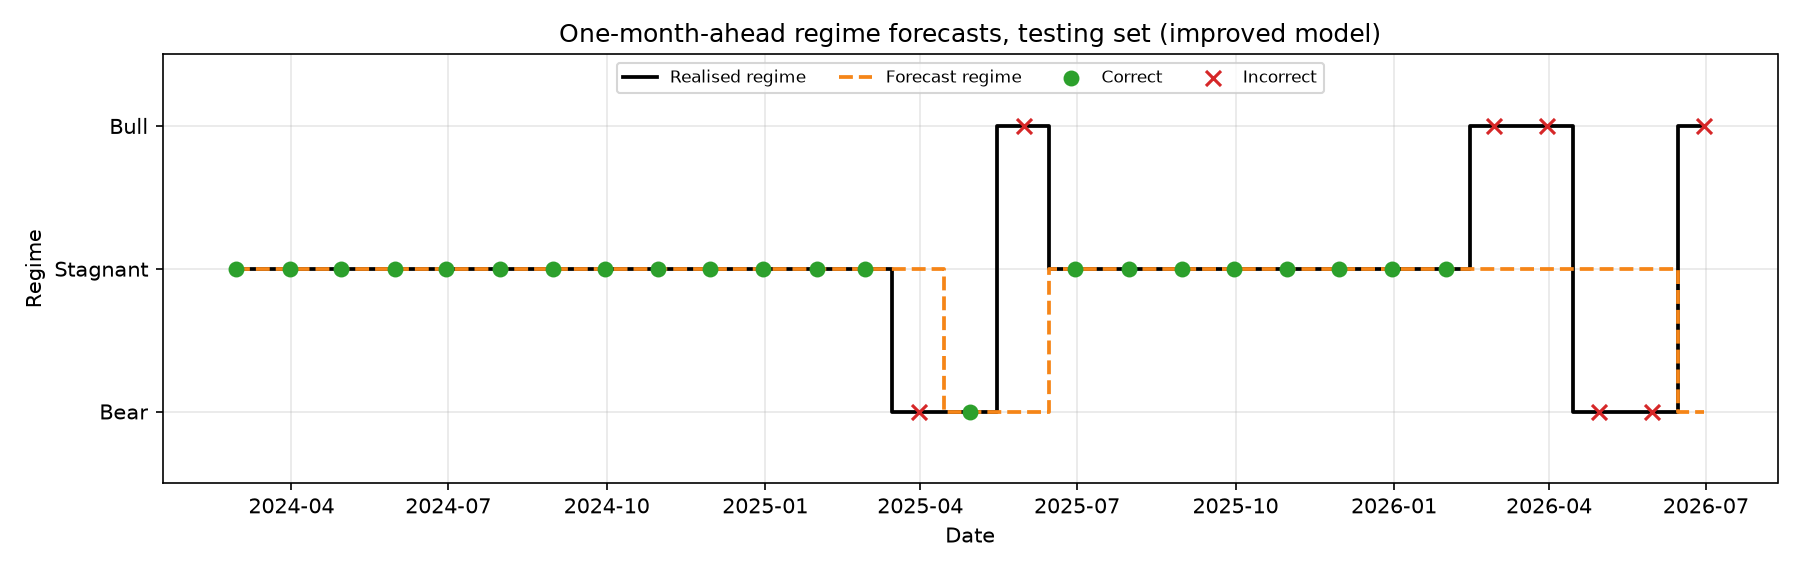

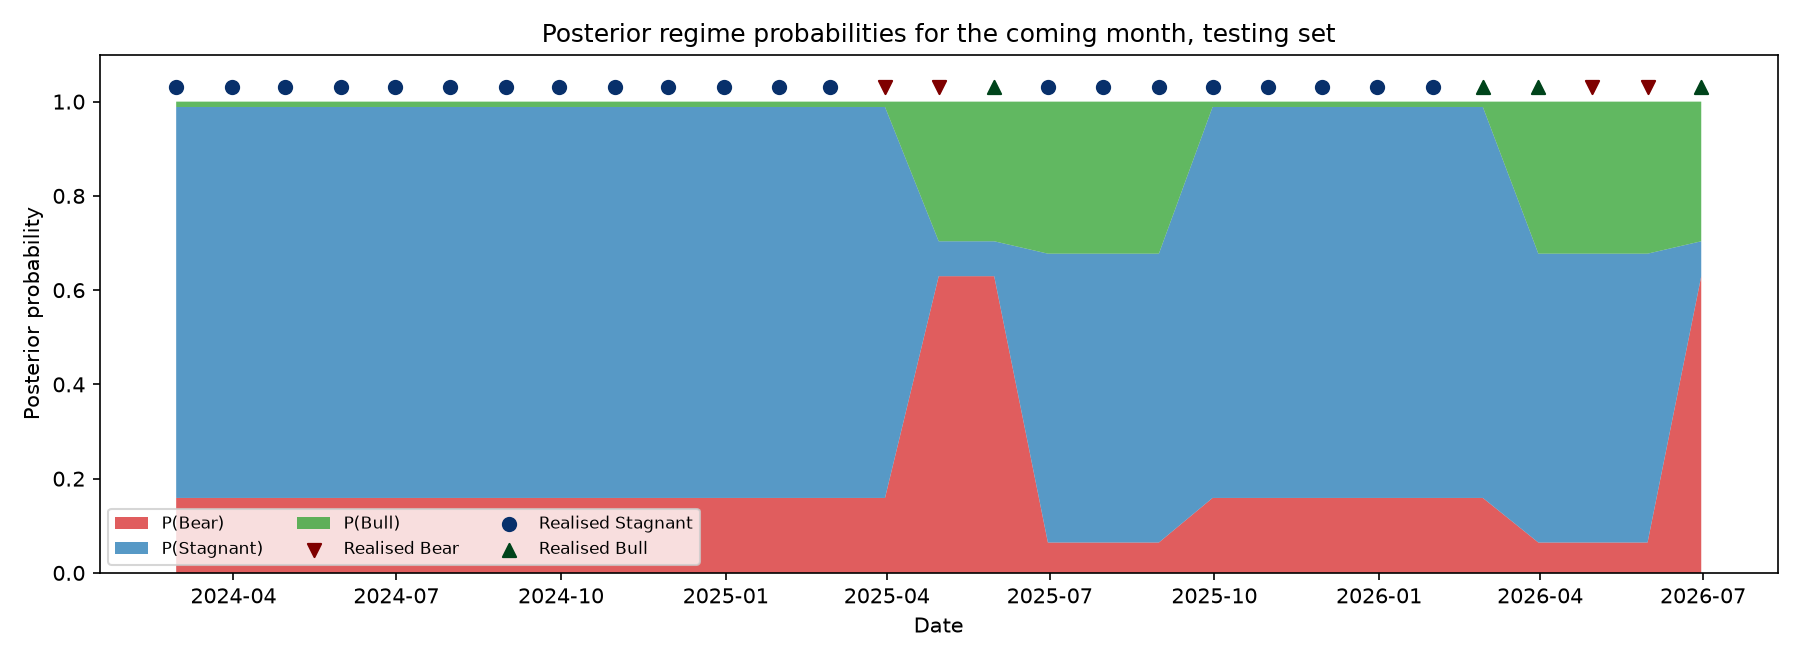

In [15]:
gwp.plot_accuracy_bars(bench, "One-month-ahead regime forecast accuracy on the testing set",
                       "accuracy_comparison.png")
gwp.plot_confusion(sA_test["confusion"], "Replication model, testing set",
                   "confusion_modelA_test.png")
gwp.plot_confusion(sB_test["confusion"], "Improved model, testing set",
                   "confusion_modelB_test.png")
gwp.plot_timeline(A["test"].index, sA_test["y_true"], sA_test["y_pred"],
                  "One-month-ahead regime forecasts, testing set (replication model)",
                  "timeline_modelA_test.png")
gwp.plot_timeline(B["test"].index, sB_test["y_true"], sB_test["y_pred"],
                  "One-month-ahead regime forecasts, testing set (improved model)",
                  "timeline_modelB_test.png")
gwp.plot_posterior(B["test"].index, prob_test, yB,
                   "Posterior regime probabilities for the coming month, testing set",
                   "posterior_modelC.png")
for f in ["accuracy_comparison", "confusion_modelA_test", "confusion_modelB_test",
          "timeline_modelA_test", "timeline_modelB_test", "posterior_modelC"]:
    display(Image(f"{FIG}/{f}.png"))

,Rule,Start,Terminal_value,Buy_and_hold
0,Replication model,79.22,79.15,79.20
1,Improved model,79.22,110.12,70.56
2,Expected-return rule,79.22,156.99,70.56


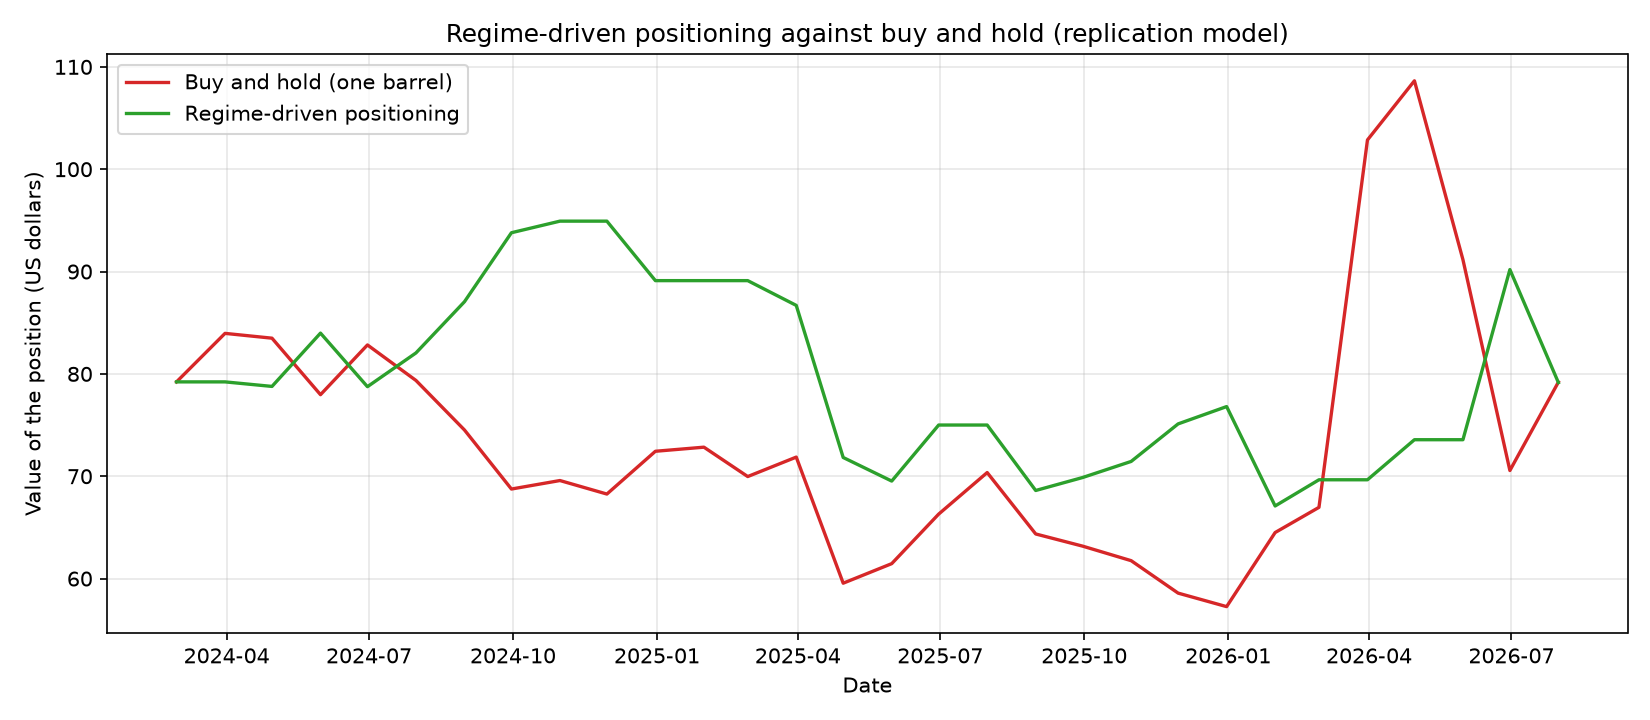

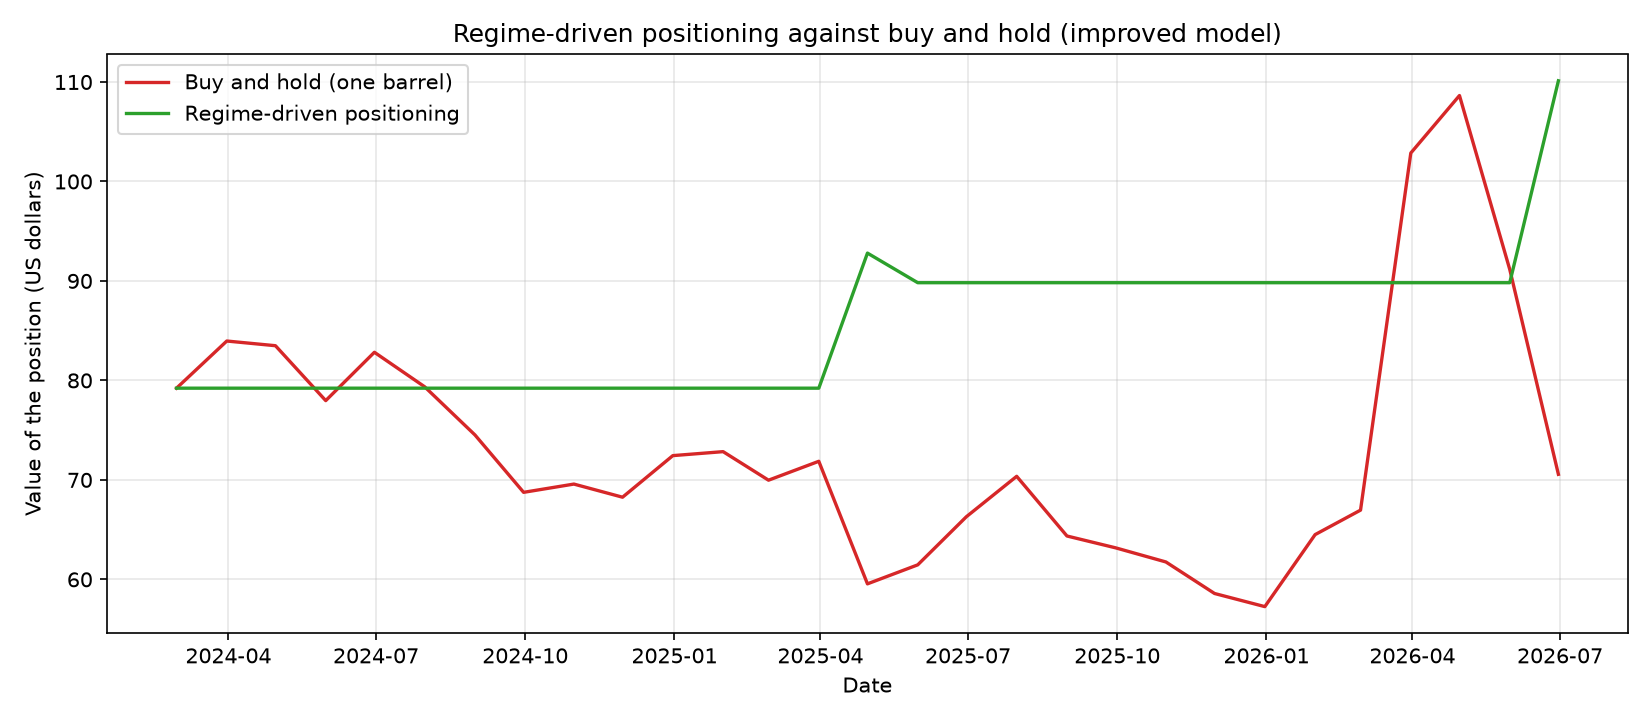

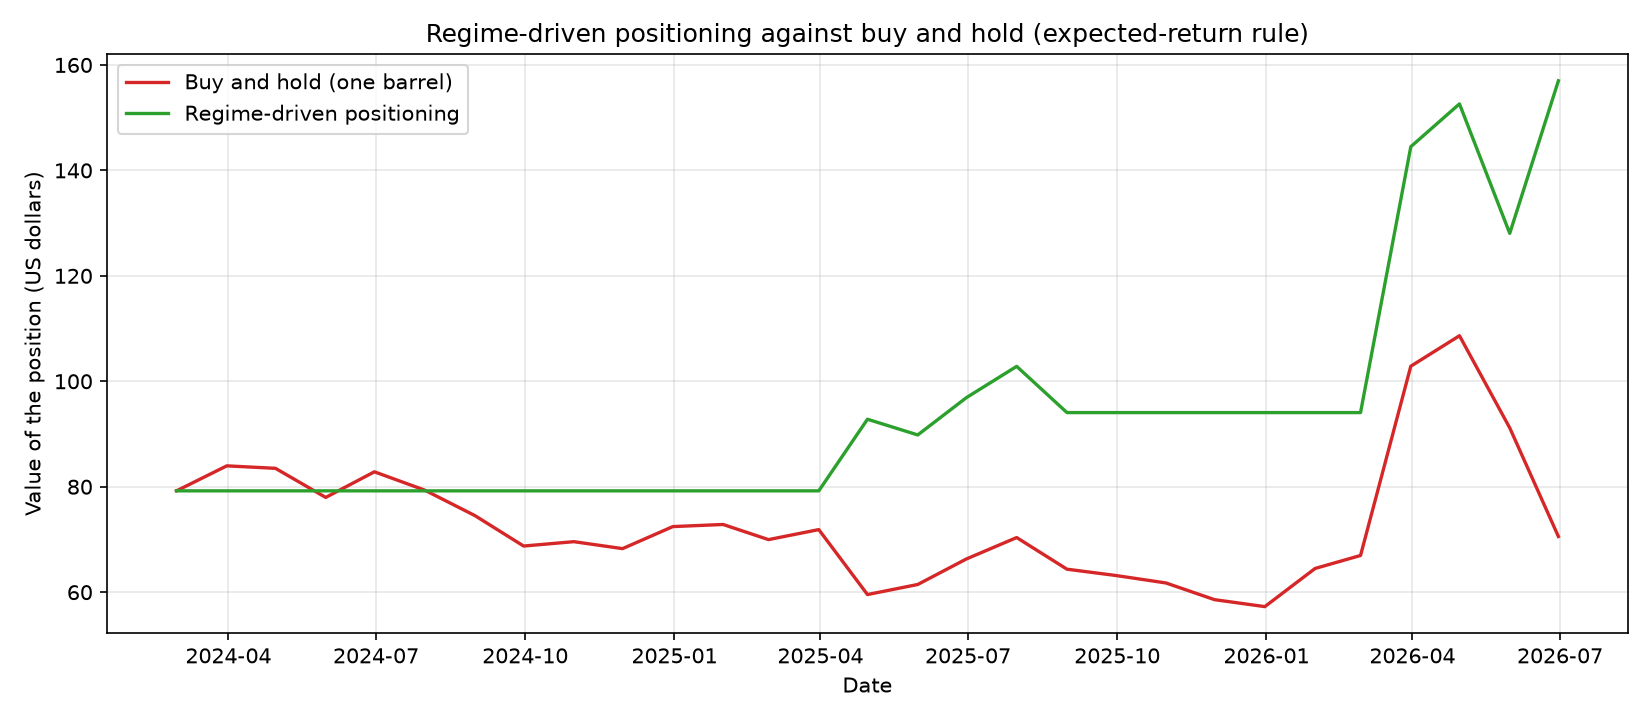

In [16]:
pxA = df[gwp.TARGET].loc[A["test"].index]
pxB = df[gwp.TARGET].loc[B["test"].index]
sa, ha = gwp.plot_strategy(pxA, sA_test["y_pred"],
    "Regime-driven positioning against buy and hold (replication model)", "strategy_modelA.png")
sb, hb = gwp.plot_strategy(pxB, sB_test["y_pred"],
    "Regime-driven positioning against buy and hold (improved model)", "strategy_modelB.png")
sc, hc = gwp.plot_strategy(pxB, rule_pred,
    "Regime-driven positioning against buy and hold (expected-return rule)", "strategy_modelC.png")
display(pd.DataFrame([
    dict(Rule="Replication model", Start=round(float(pxA.iloc[0]), 2),
         Terminal_value=round(sa, 2), Buy_and_hold=round(ha, 2)),
    dict(Rule="Improved model", Start=round(float(pxB.iloc[0]), 2),
         Terminal_value=round(sb, 2), Buy_and_hold=round(hb, 2)),
    dict(Rule="Expected-return rule", Start=round(float(pxB.iloc[0]), 2),
         Terminal_value=round(sc, 2), Buy_and_hold=round(hc, 2))]))
for f in ["strategy_modelA", "strategy_modelB", "strategy_modelC"]:
    display(Image(f"{FIG}/{f}.png"))

**Interpretation.** Read together, the three specifications tell a consistent story.

The **replication model** is worse than guessing (23.3 per cent, exact 95 per cent interval 9.9 to
42.3 per cent), for the structural reason set out in Question 4.

The **improved model** classifies 75.9 per cent of the months correctly (interval 56.5 to 89.7 per
cent), which is above the majority-regime benchmark of 72.4 per cent but below the persistence
benchmark of 79.3 per cent. The exact McNemar tests give p-values of 1.00 against both benchmarks:
on thirty months, the belief network is statistically indistinguishable from simply repeating last
month's regime. Its balanced accuracy of 41.7 per cent exposes the reason — the maximum a
posteriori rule almost always answers *stagnant*, the modal state, and never issues a bull call.

The **expected-return rule** addresses precisely that failure. By scoring the posterior with the
economic consequence of each regime rather than with its probability alone, it sacrifices raw
accuracy (69.0 per cent) for a materially better balanced accuracy (45.2 per cent) and macro
F1 (45.5 per cent), it issues directional calls in 31 per cent of months and is right in 66.7 per
cent of them, and its positioning ends the testing window at 157.0 dollars against 70.6 dollars
for a barrel held throughout. That backtest ignores transaction costs, financing and slippage and
rests on nine directional calls, so it is an illustration of the decision rule, not a performance
claim.

The honest conclusion is that the belief network extracts a small amount of information about the
direction of the crude oil market, that this information is not statistically significant on a
thirty-month hold-out sample, and that how the posterior is converted into a decision matters as
much as the network itself.

---
## Question 6 — The eight contributions claimed by the dissertation

The claims are listed in the conclusions of the dissertation (Alvi 2018, pp. 66-67). The detailed
assessment, with page and figure citations, is developed in the written report; the table below
summarises the verdicts and the evidence used to reach them.

In [17]:
contrib = pd.DataFrame([
 dict(Claim="1. Bayesian views replace EGARCH-M views in a Black-Litterman model",
      Evidence="pp. 66-67; ref. [15] Beach and Orlov (2007)", Verdict="Not achieved",
      Basis="Proposed in the conclusions only; no Black-Litterman allocation is implemented or tested anywhere in the dissertation"),
 dict(Claim="2. Time series discretised by hidden Markov models used as inputs to belief networks",
      Evidence="Sections 3.3, 4.2-4.2.5, pp. 42-43 and 54-58", Verdict="Achieved",
      Basis="Implemented end to end and reproduced here; novelty is a matter of degree, but the mechanism works"),
 dict(Claim="3. A working trading mechanism capable of independent decisions",
      Evidence="Section 4.3.1, pp. 64-65", Verdict="Partially achieved",
      Basis="A long/short rule and an equity curve are shown for 28 months without costs or risk limits"),
 dict(Claim="4. An autonomous system requiring no prior expert knowledge",
      Evidence="Section 4.2.6 and p. 59", Verdict="Partially achieved",
      Basis="Hill climbing is seeded with an expert EIA structure; our seeded and unseeded searches differ, so the claim is only true of the unseeded variant"),
 dict(Claim="5. The abstraction of the Python modelling libraries clarifies the design process",
      Evidence="Sections 2.2.1-2.2.2, pp. 28-29", Verdict="Achieved",
      Basis="A presentational contribution; the libraries used are third-party and the point is pedagogical"),
 dict(Claim="6. A systematic event-driven global macro strategy yielding higher returns than high-frequency or fixed-income funds",
      Evidence="Section 4.3.1, p. 65", Verdict="Not achieved",
      Basis="No comparison with any fund is performed; the only benchmark shown is the EIA Short Term Energy Outlook"),
 dict(Claim="7. Better models of energy markets to inform policy",
      Evidence="Section 3.4, pp. 43-45; Figure on p. 60", Verdict="Partially achieved",
      Basis="The learned graph is plausible but unstable; our own search returns different edge sets under different scores"),
 dict(Claim="8. Amalgamation of existing research to increase alpha for commodity traders",
      Evidence="Chapter 5, p. 67", Verdict="Partially achieved",
      Basis="The synthesis is real; the alpha claim is unsupported by any risk-adjusted measure")])
pd.set_option("display.max_colwidth", 90)
display(contrib)

,Claim,Evidence,Verdict,Basis
0,1. Bayesian views replace EGARCH-M views in a Black-Litterman model,pp. 66-67; ref. [15] Beach and Orlov (2007),Not achieved,Proposed in the conclusions only; no Black-Litterman allocation is implemented or test...
1,2. Time series discretised by hidden Markov models used as inputs to belief networks,"Sections 3.3, 4.2-4.2.5, pp. 42-43 and 54-58",Achieved,"Implemented end to end and reproduced here; novelty is a matter of degree, but the mec..."
2,3. A working trading mechanism capable of independent decisions,"Section 4.3.1, pp. 64-65",Partially achieved,A long/short rule and an equity curve are shown for 28 months without costs or risk li...
3,4. An autonomous system requiring no prior expert knowledge,Section 4.2.6 and p. 59,Partially achieved,Hill climbing is seeded with an expert EIA structure; our seeded and unseeded searches...
4,5. The abstraction of the Python modelling libraries clarifies the design process,"Sections 2.2.1-2.2.2, pp. 28-29",Achieved,A presentational contribution; the libraries used are third-party and the point is ped...
5,6. A systematic event-driven global macro strategy yielding higher returns than high-f...,"Section 4.3.1, p. 65",Not achieved,No comparison with any fund is performed; the only benchmark shown is the EIA Short Te...
6,7. Better models of energy markets to inform policy,"Section 3.4, pp. 43-45; Figure on p. 60",Partially achieved,The learned graph is plausible but unstable; our own search returns different edge set...
7,8. Amalgamation of existing research to increase alpha for commodity traders,"Chapter 5, p. 67",Partially achieved,The synthesis is real; the alpha claim is unsupported by any risk-adjusted measure


---
## Question 7 — Non-technical discussion

**What was found.** Using publicly available monthly information on oil prices, the dollar,
inflation, interest rates and industrial production, we built a system that classifies the crude
oil market into three conditions — falling, flat and rising — and estimates the chance that each
condition prevails next month. Over the most recent thirty months, the system identified the
prevailing condition in roughly three months out of four, and when it took a directional view it
was right two times out of three.

**What follows for an investment decision.** The system is useful as a discipline for sizing risk,
not as a signal to trade on its own. Because it usually reports that the market is flat, its main
practical value is that it flags the small number of months in which the evidence points clearly
up or down. A desk can act on those months and stand aside otherwise. Any position taken on this
basis should be small, should carry a stop, and should be reviewed monthly as new figures arrive.
The apparent profitability shown in the backtest rests on nine decisions and excludes trading
costs, so it should be treated as an illustration rather than as a track record.

**What moves the result.** Three factors dominate. First, the strength of the dollar and the level
of policy rates: when financing is expensive and the dollar is strong, the oil market is more
often in the falling condition. Second, industrial activity, which stands in for demand. Third,
and most important, the definition of the market condition itself: a definition based only on
whether the price rose or fell is unusable, whereas one based on the size of the move produces
conditions that persist for several months and can be acted upon. A reader who takes one thing
from this study should take that: the quality of the answer depends far more on how the market
state is defined than on the sophistication of the model that consumes it.